# Employee Performance Analysis — INX Future Inc.
## Visualisation & Exploratory Analysis

**Business Case:** Visually explore all 28 features of the employee dataset to understand distributions, inter-feature relationships, and their impact on `PerformanceRating`.

---
### Visualisation Plan
| Analysis Type | Goal |
|---|---|
| **Domain Analysis** | Understand the meaning and expected impact of each feature |
| **Univariate Analysis** | Distribution and frequency of individual features |
| **Bivariate Analysis** | Pairwise relationships between features |
| **Multivariate Analysis** | Relationships between two features with respect to the target |

### IMPORTING THE NECESSAERY LIBRARIES

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')  # setting up background
from scipy import stats

# TO avoid warnings
import warnings 
warnings.filterwarnings('ignore')

### READING DATA FOR VISUALIZATION:

In [3]:
data = pd.read_excel(r"C:\Users\admin\Desktop\IABAC PROJECT\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8 (1).xls")
pd.set_option('display.max_columns',None) # Used to display the all features
data.head() # Get first 5 rows

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


---
## Domain Analysis — Feature Descriptions

Understanding each feature's meaning helps interpret patterns in visualisations.

| # | Feature | Description |
|---|---|---|
| 1 | `EmpNumber` | Unique alphanumeric employee identifier — not predictive |
| 2 | `Age` | Age of the employee in years |
| 3 | `Gender` | Gender of the employee (Male / Female) |
| 4 | `EducationBackground` | Highest academic field of study |
| 5 | `MaritalStatus` | Marital status (Married / Single / Divorced) |
| 6 | `EmpDepartment` | Department the employee belongs to |
| 7 | `EmpJobRole` | Specific job role within the department |
| 8 | `BusinessTravelFrequency` | Frequency of business travel |
| 9 | `DistanceFromHome` | Commute distance in km |
| 10 | `EmpEducationLevel` | Academic qualification level (1–5) |
| 11 | `EmpEnvironmentSatisfaction` | Satisfaction with the workplace environment (1–4) |
| 12 | `EmpHourlyRate` | Hourly pay rate |
| 13 | `EmpJobInvolvement` | Degree of psychological identification with the job (1–4) |
| 14 | `EmpJobLevel` | Seniority / responsibility level (1–5) |
| 15 | `EmpJobSatisfaction` | Overall job satisfaction score (1–4) |
| 16 | `NumCompaniesWorked` | Number of previous employers |
| 17 | `OverTime` | Whether the employee works overtime (Yes / No) |
| 18 | `EmpLastSalaryHikePercent` | Percentage salary hike received last year |
| 19 | `EmpRelationshipSatisfaction` | Satisfaction with workplace relationships (1–4) |
| 20 | `TotalWorkExperienceInYears` | Total career experience in years |
| 21 | `TrainingTimesLastYear` | Number of training sessions attended last year |
| 22 | `EmpWorkLifeBalance` | Work-life balance score (1–4) |
| 23 | `ExperienceYearsAtThisCompany` | Years at INX Future Inc. |
| 24 | `ExperienceYearsInCurrentRole` | Years in current role |
| 25 | `YearsSinceLastPromotion` | Years elapsed since last promotion |
| 26 | `YearsWithCurrManager` | Years working under the current manager |
| 27 | `Attrition` | Whether the employee plans to leave (Yes / No) |
| 28 | `PerformanceRating` | **Target variable** — overall performance rating (2–4) |

---
## Univariate Analysis

**Goal:** Understand the distribution of each feature individually.

### Continuous Features — Histogram Plots

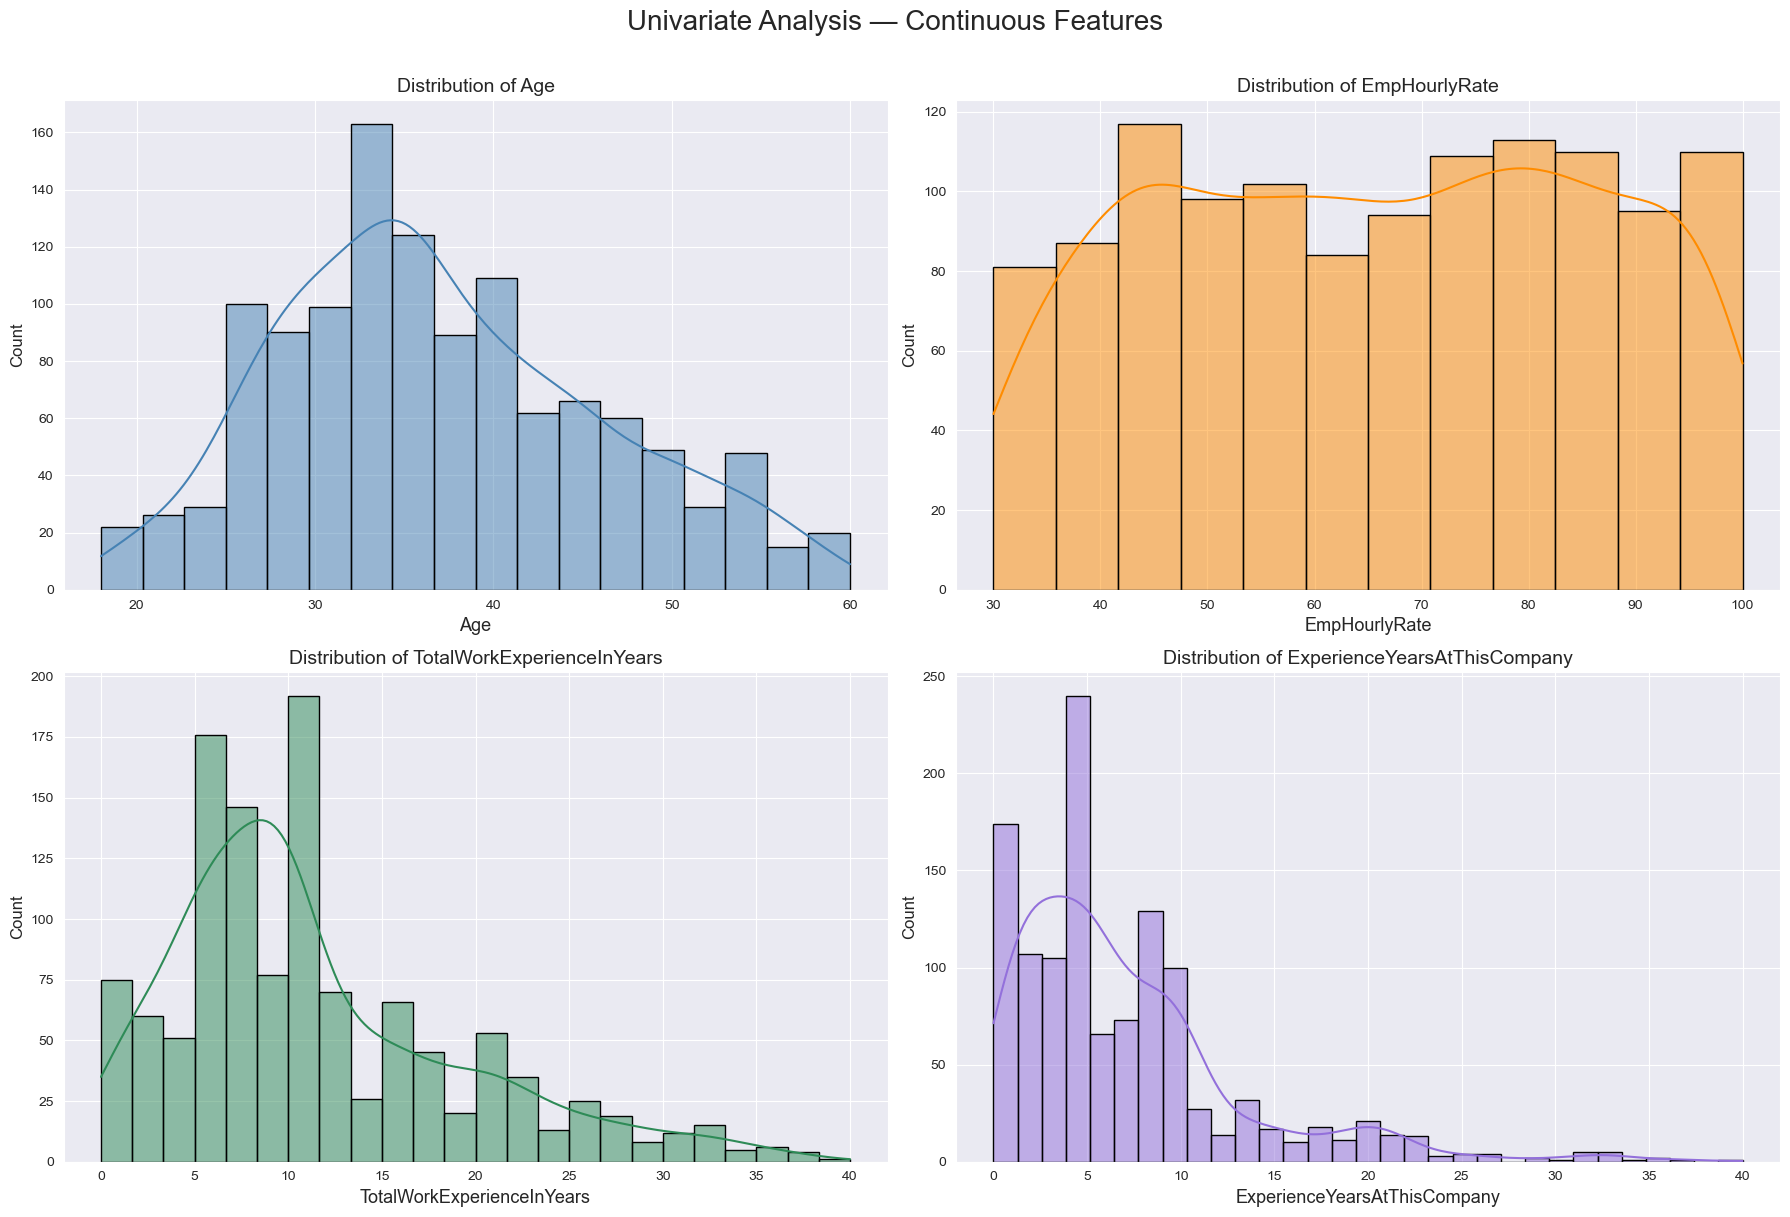

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
continuous_features = ['Age', 'EmpHourlyRate', 'TotalWorkExperienceInYears', 'ExperienceYearsAtThisCompany']
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

for ax, col, color in zip(axes.flatten(), continuous_features, colors):
    sns.histplot(data[col], ax=ax, color=color, kde=True, edgecolor='black')
    ax.set_xlabel(col, fontsize=13)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Distribution of {col}', fontsize=14)

plt.suptitle('Univariate Analysis — Continuous Features', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **Age:** Ranges from 18–60; most employees are aged 25–40.
- **EmpHourlyRate:** Most employees earn between 65–95 per hour.
- **TotalWorkExperienceInYears:** Most employees have 5–10 years of experience.
- **ExperienceYearsAtThisCompany:** Most employees have 0–5 years at INX.

### Categorical & Discrete Features — Count Plots (Set 1)

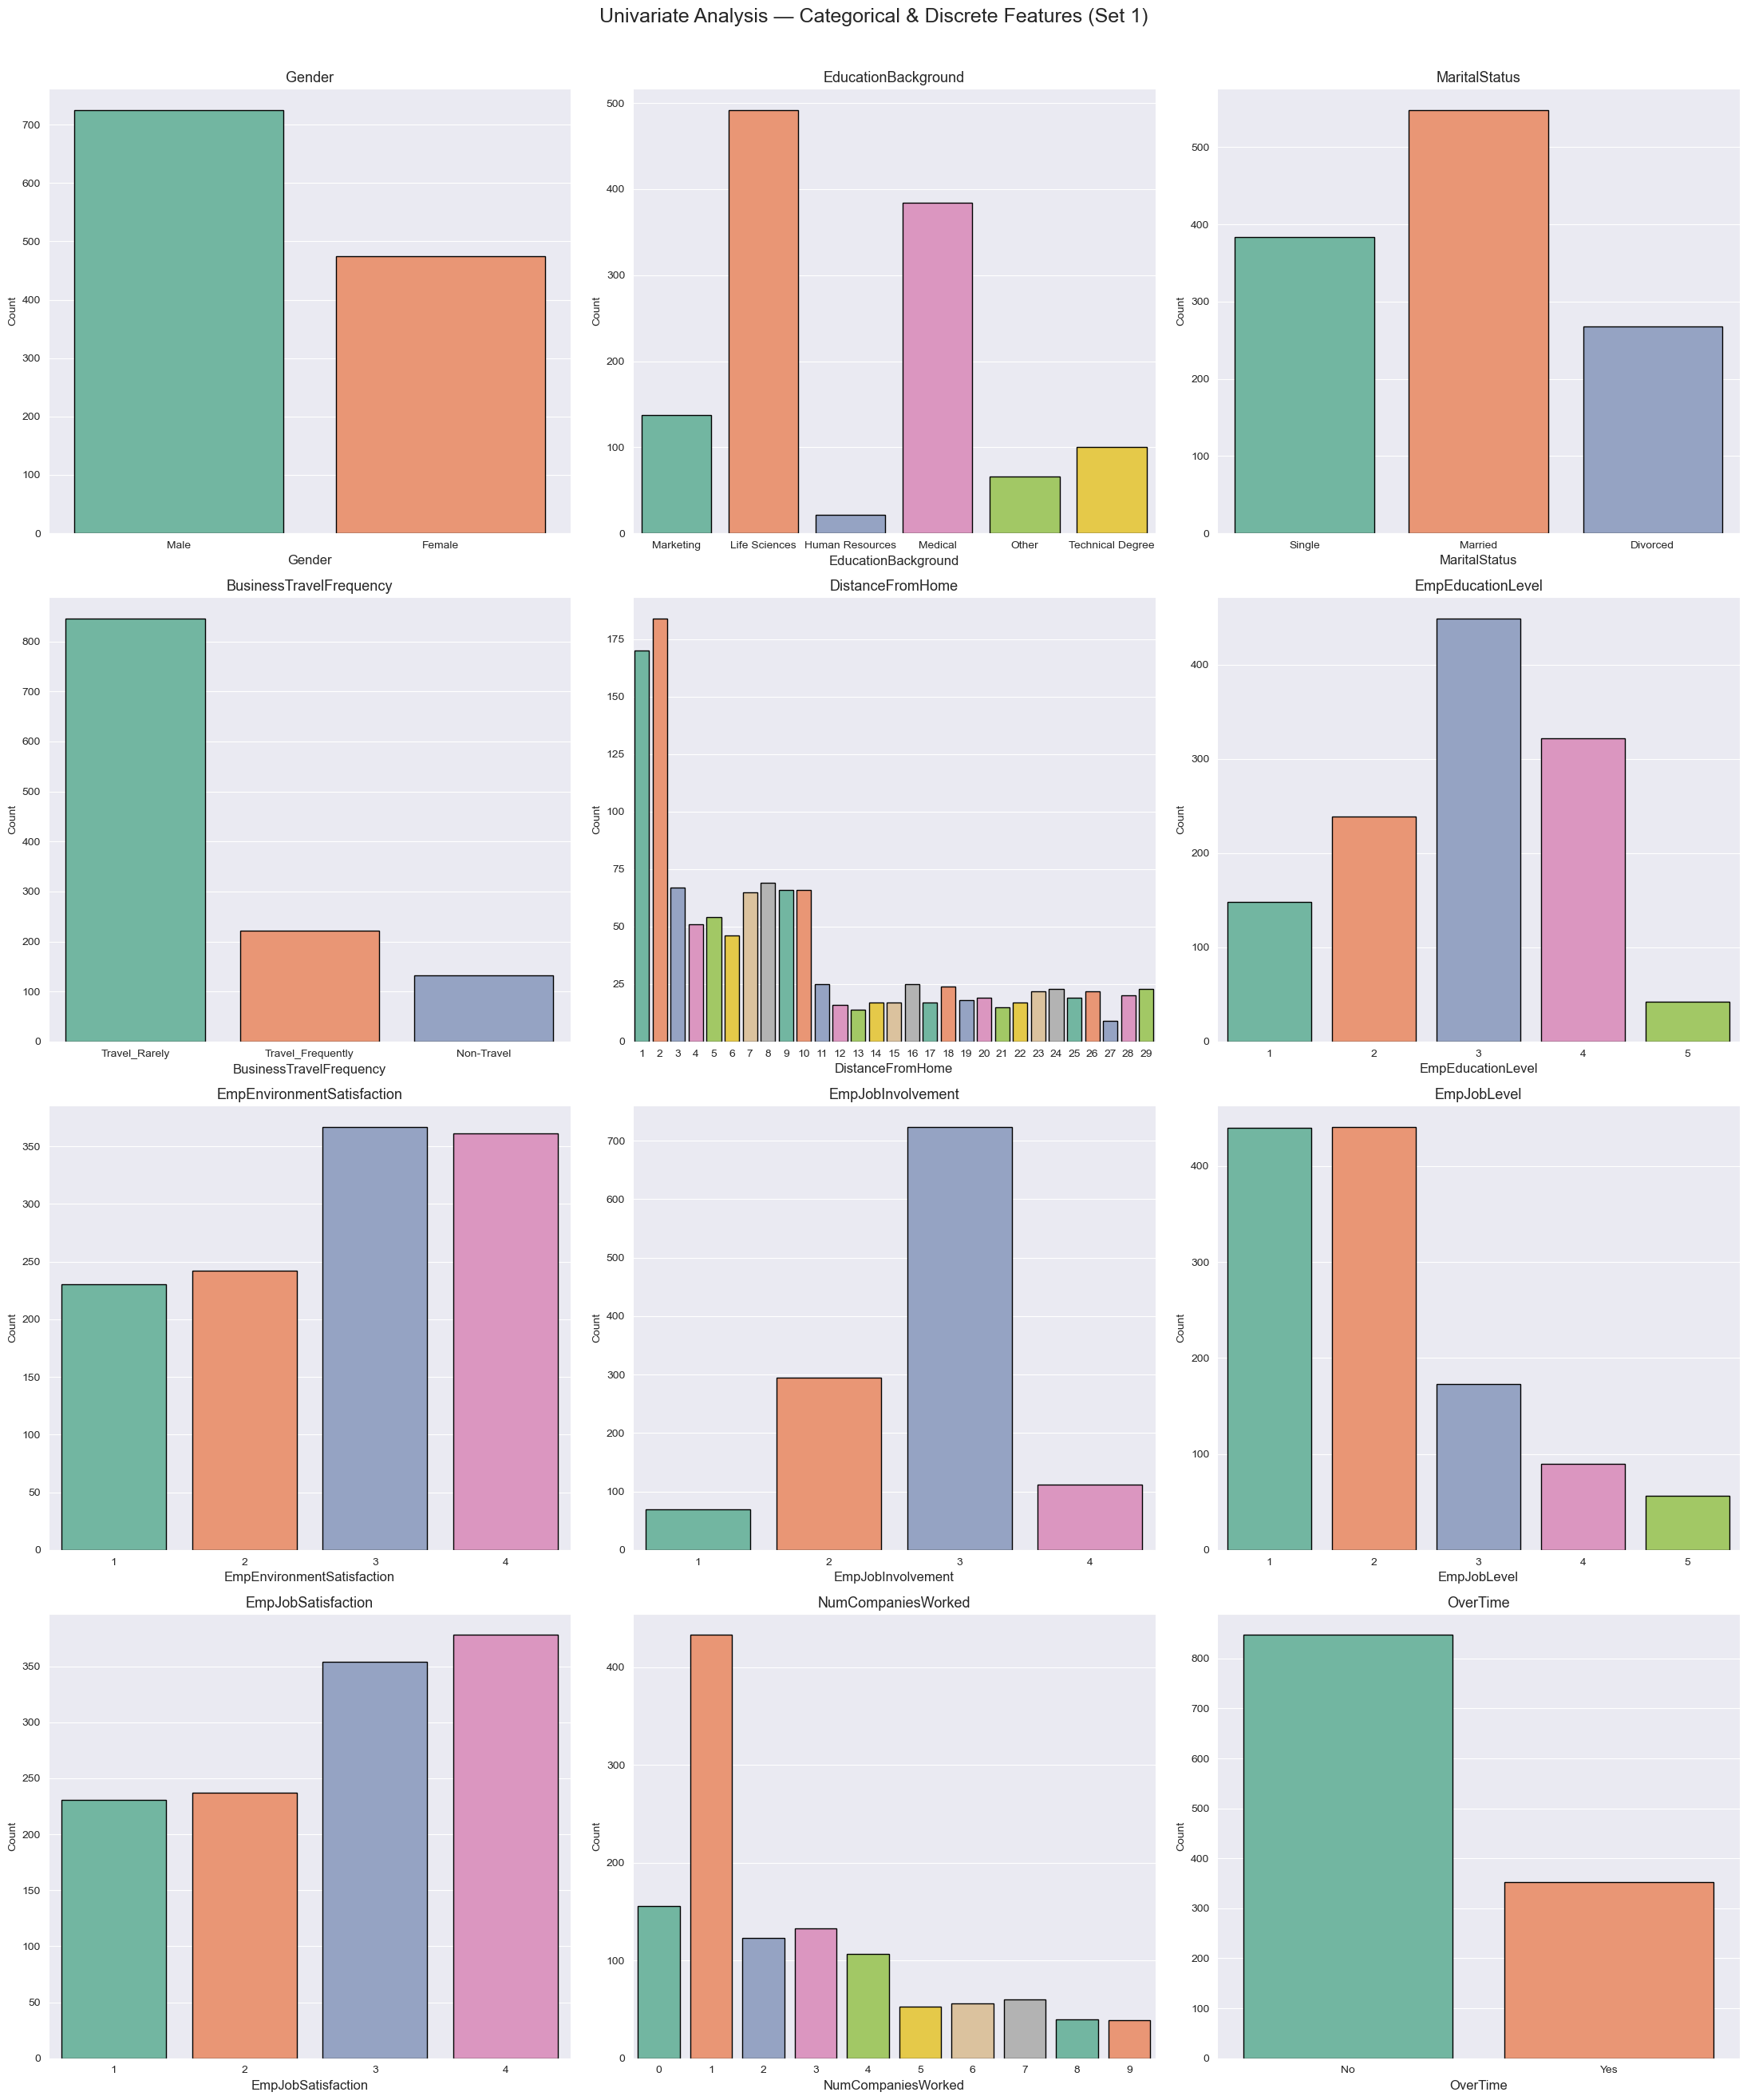

In [5]:
count_set1 = ['Gender', 'EducationBackground', 'MaritalStatus', 'BusinessTravelFrequency',
               'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
               'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction',
               'NumCompaniesWorked', 'OverTime']

plt.figure(figsize=(22, 26))
for i, col in enumerate(count_set1, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=data[col], palette='Set2', edgecolor='black')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=10)
    plt.title(col, fontsize=13)
plt.suptitle('Univariate Analysis — Categorical & Discrete Features (Set 1)', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()


**Key Observations:**
- **Gender:** More male employees than female.
- **EducationBackground:** Life Sciences and Medical backgrounds are most common.
- **MaritalStatus:** Majority are married; fewer are divorced.
- **BusinessTravelFrequency:** Most employees travel rarely; fewer are frequent travellers.
- **EmpEnvironmentSatisfaction:** Most employees score 3 or 4.
- **OverTime:** Fewer than 350 employees work overtime.

### Categorical & Discrete Features — Count Plots (Set 2)

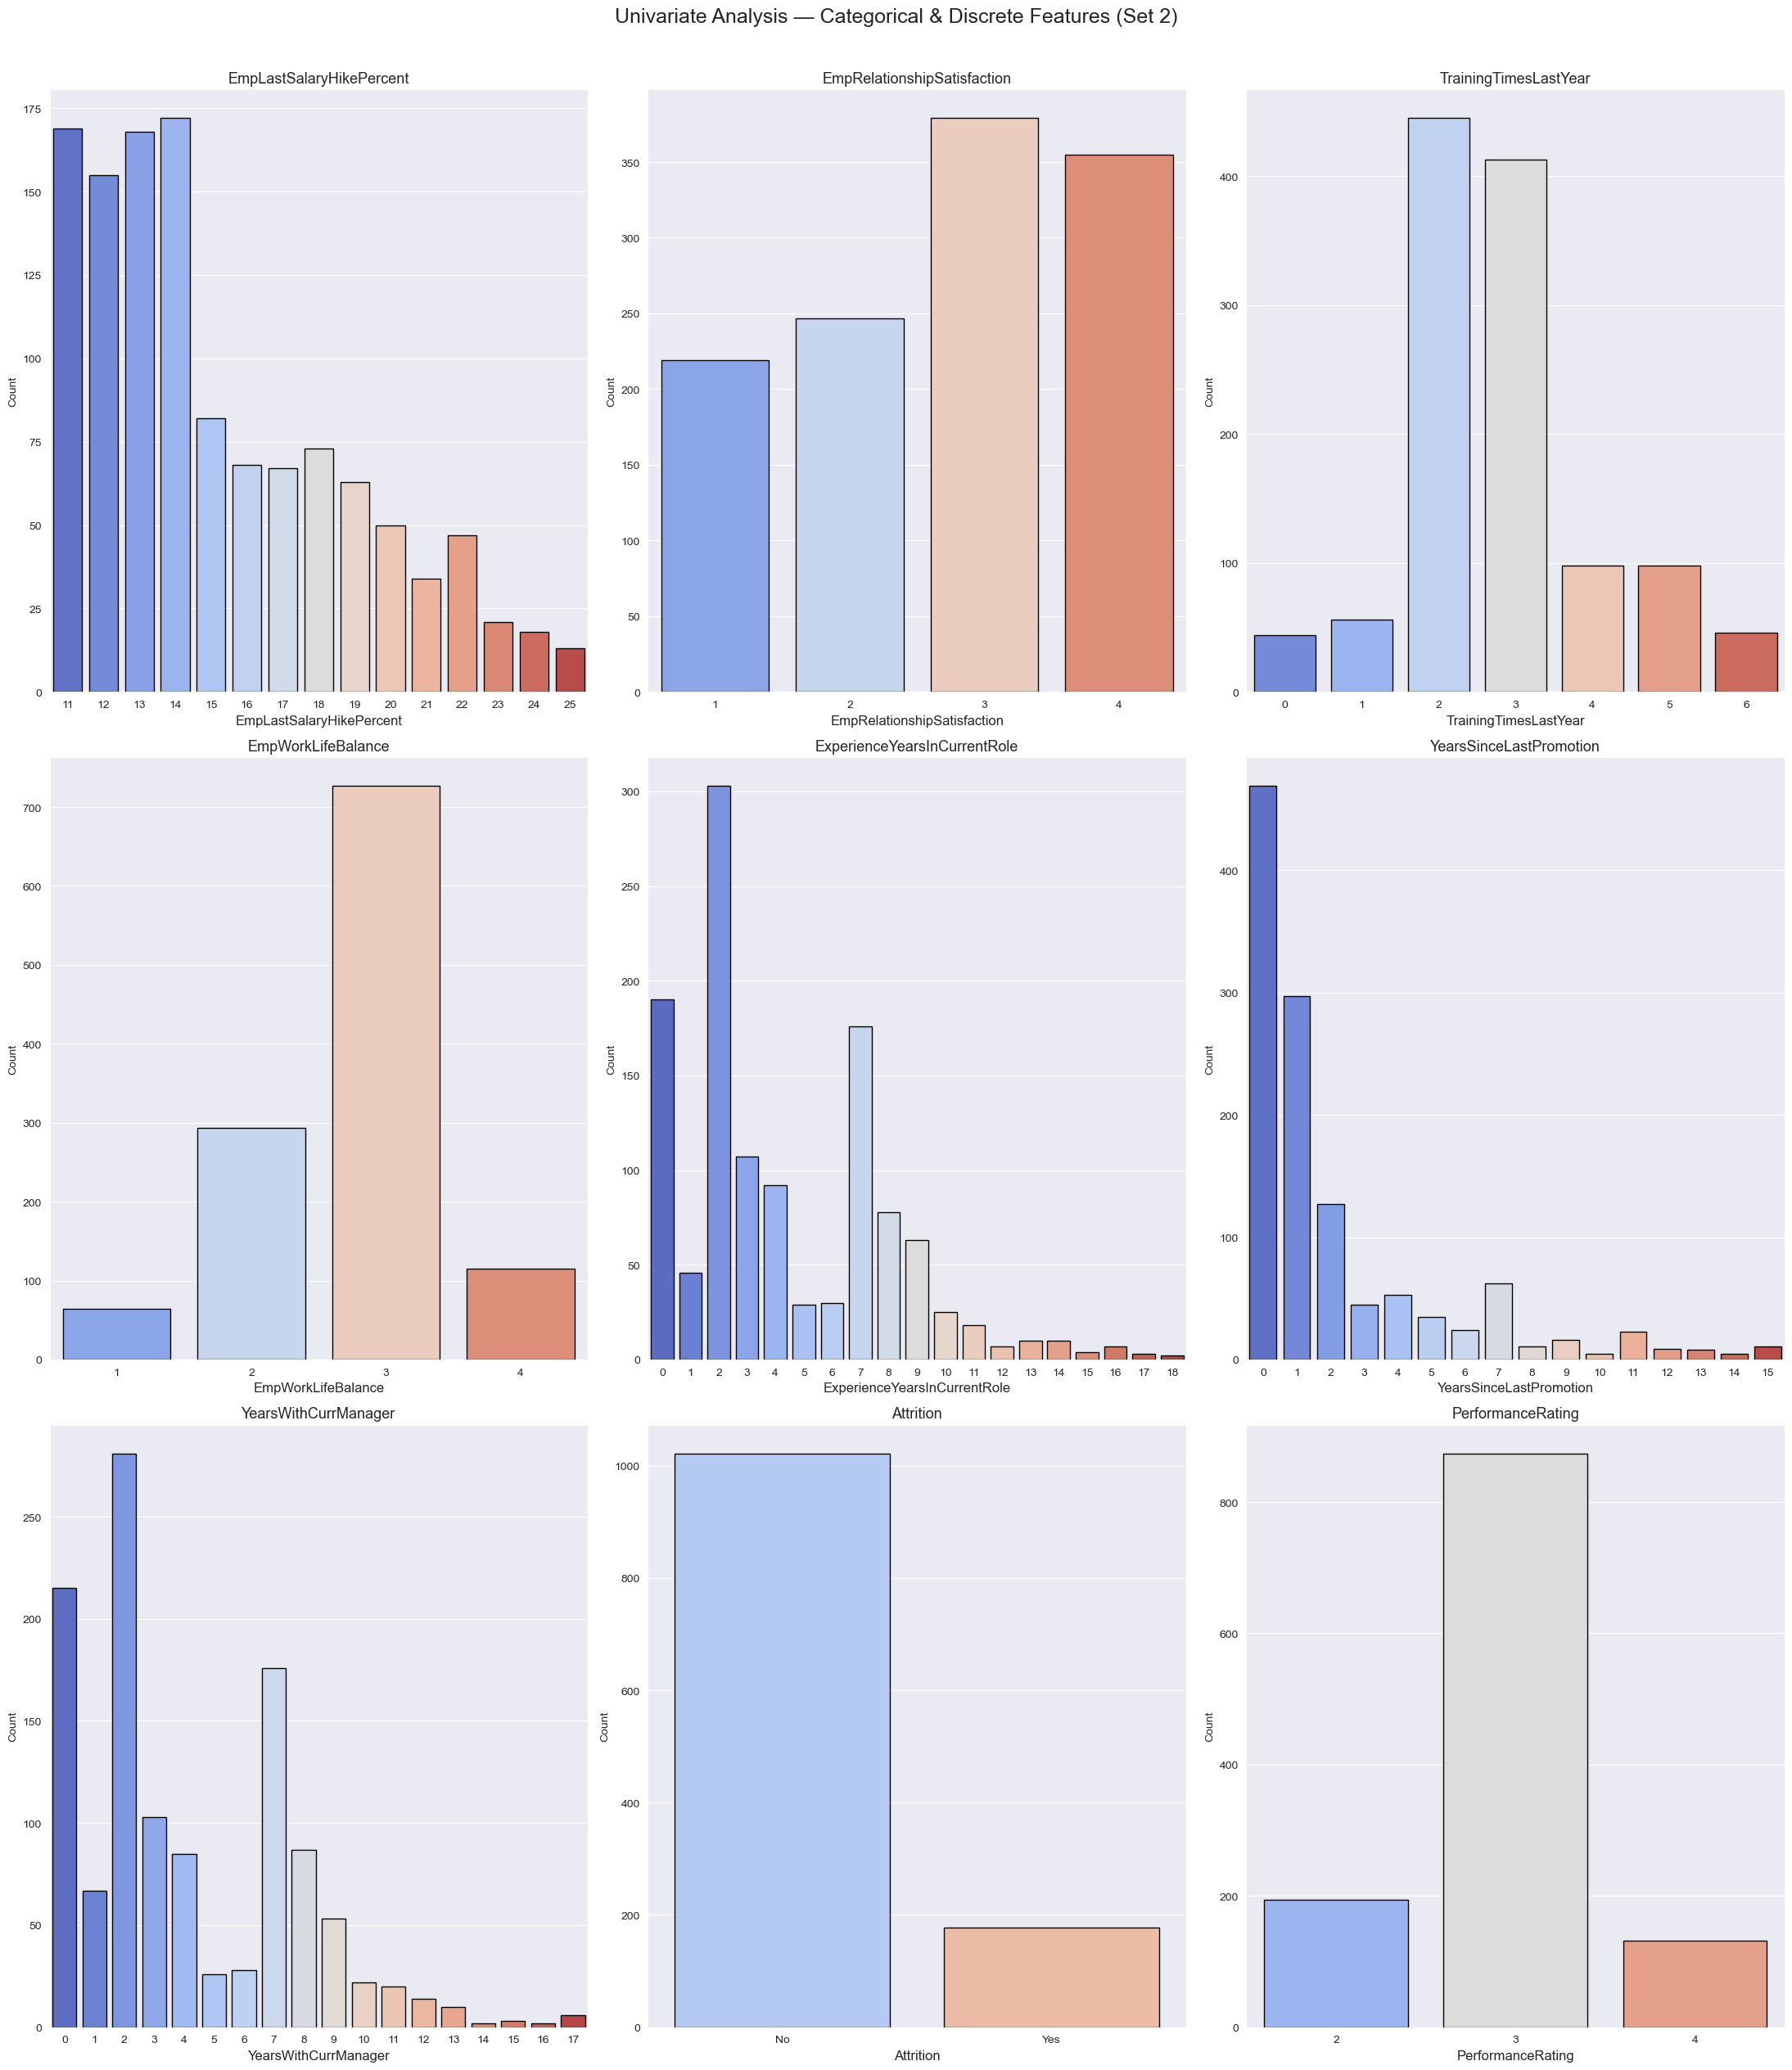

In [6]:
count_set2 = ['EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TrainingTimesLastYear',
               'EmpWorkLifeBalance', 'ExperienceYearsInCurrentRole',
               'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition', 'PerformanceRating']

plt.figure(figsize=(22, 25))
for i, col in enumerate(count_set2, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=data[col], palette='coolwarm', edgecolor='black')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=10)
    plt.title(col, fontsize=13)
plt.suptitle('Univariate Analysis — Categorical & Discrete Features (Set 2)', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

**Key Observations:**
- **EmpLastSalaryHikePercent:** Most hikes fall between 11–14%.
- **EmpWorkLifeBalance:** Level 3 is most common; level 1 is very rare.
- **PerformanceRating (Target):** Majority of employees have rating 3; fewer have rating 2 or 4 — confirming class imbalance.
- **Attrition:** Most employees are not leaving; fewer than 200 plan to leave.

### Employee Department & Job Role Distributions

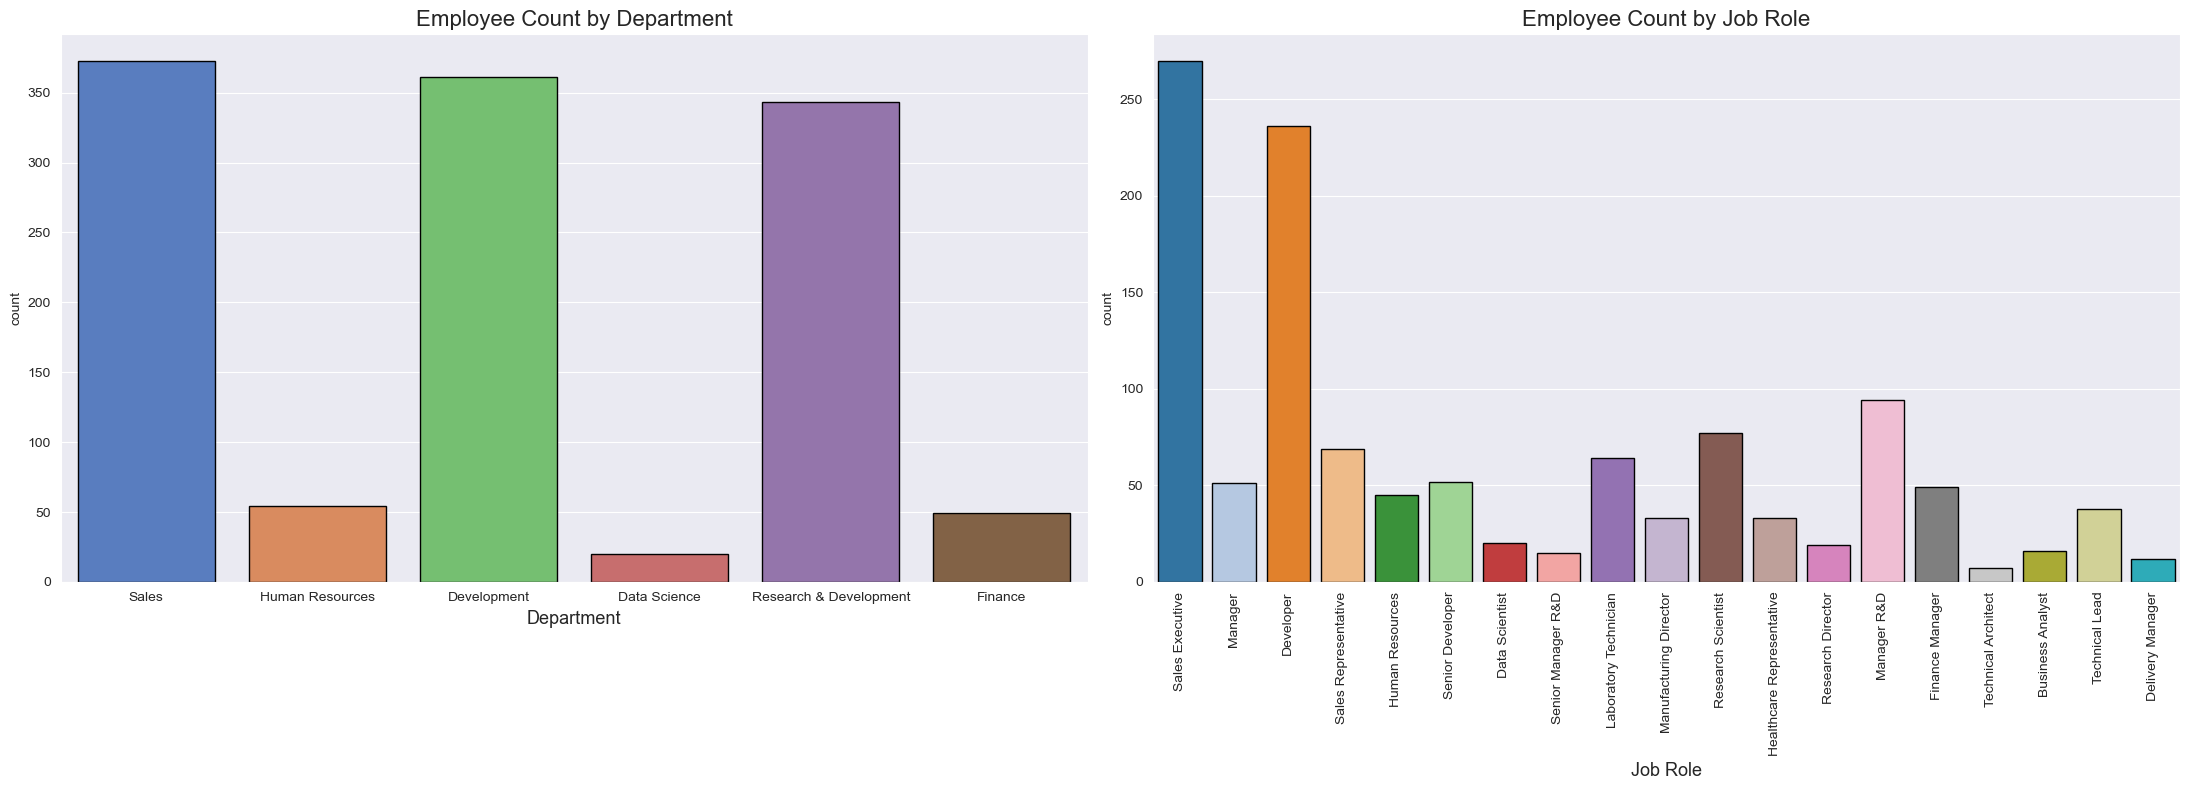

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.countplot(x='EmpDepartment', data=data, palette='muted', ax=axes[0], edgecolor='black')
axes[0].set_title('Employee Count by Department', fontsize=16)
axes[0].set_xlabel('Department', fontsize=13)

sns.countplot(x='EmpJobRole', data=data, palette='tab20', ax=axes[1], edgecolor='black')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_title('Employee Count by Job Role', fontsize=16)
axes[1].set_xlabel('Job Role', fontsize=13)

plt.tight_layout()
plt.show()

---
## Bivariate Analysis

**Goal:** Examine pairwise relationships between features.

### Continuous Features vs Continuous Features

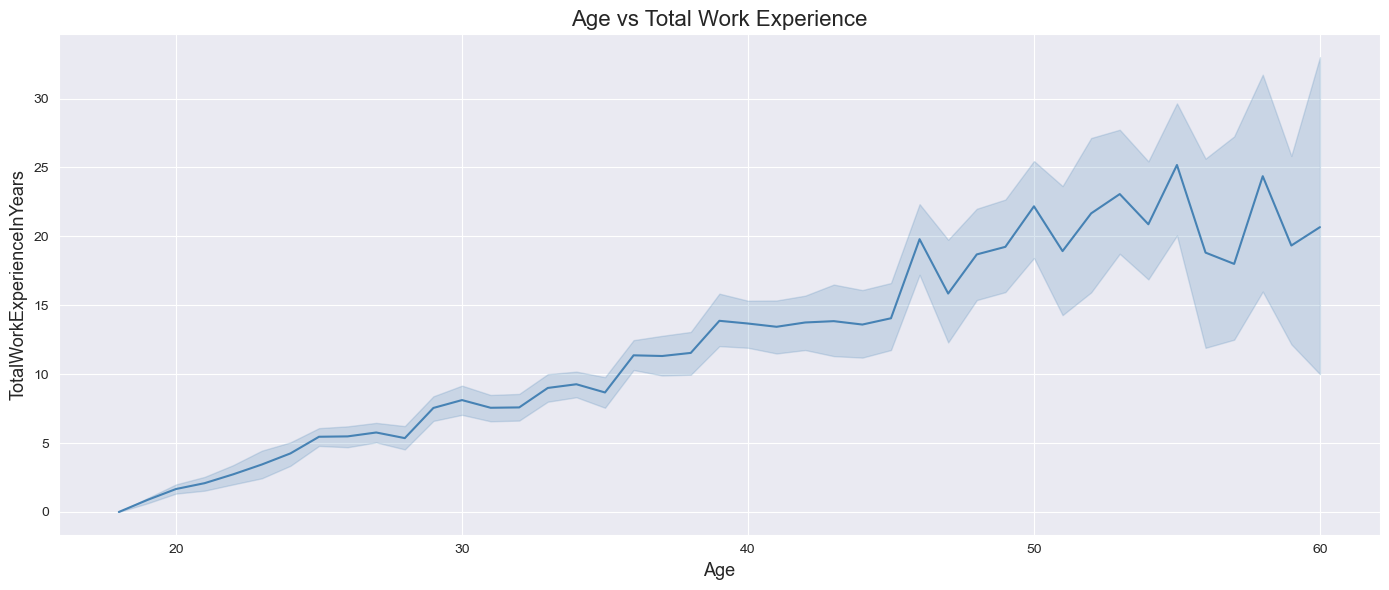

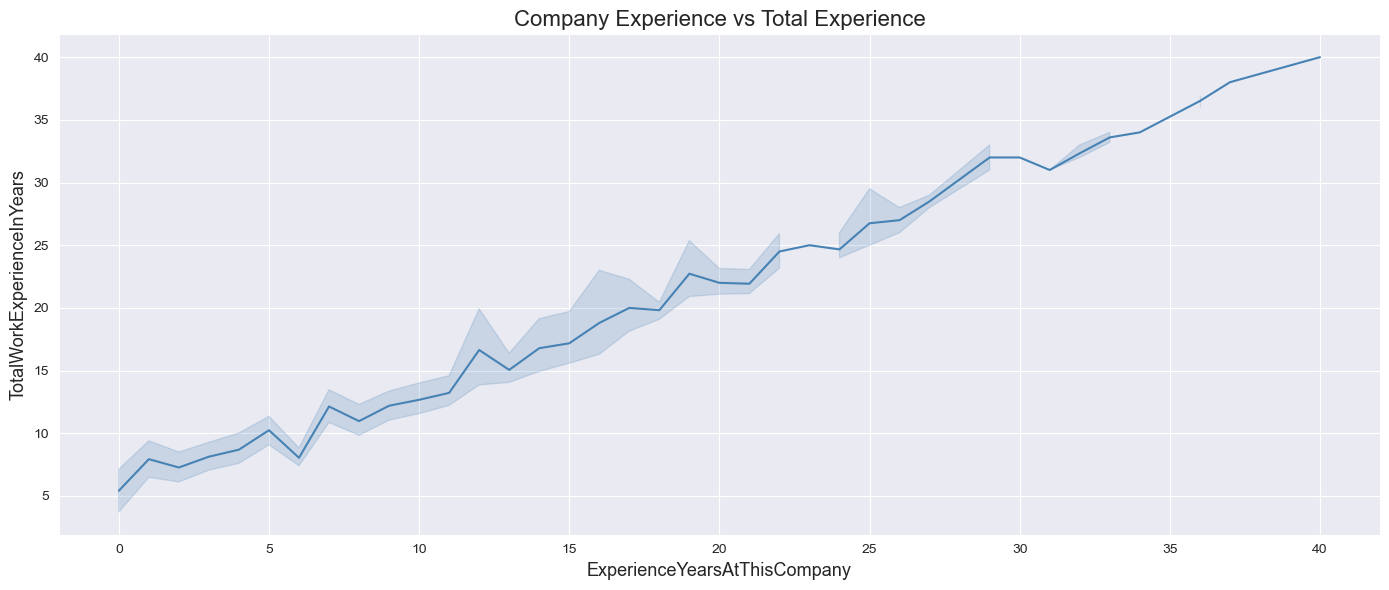

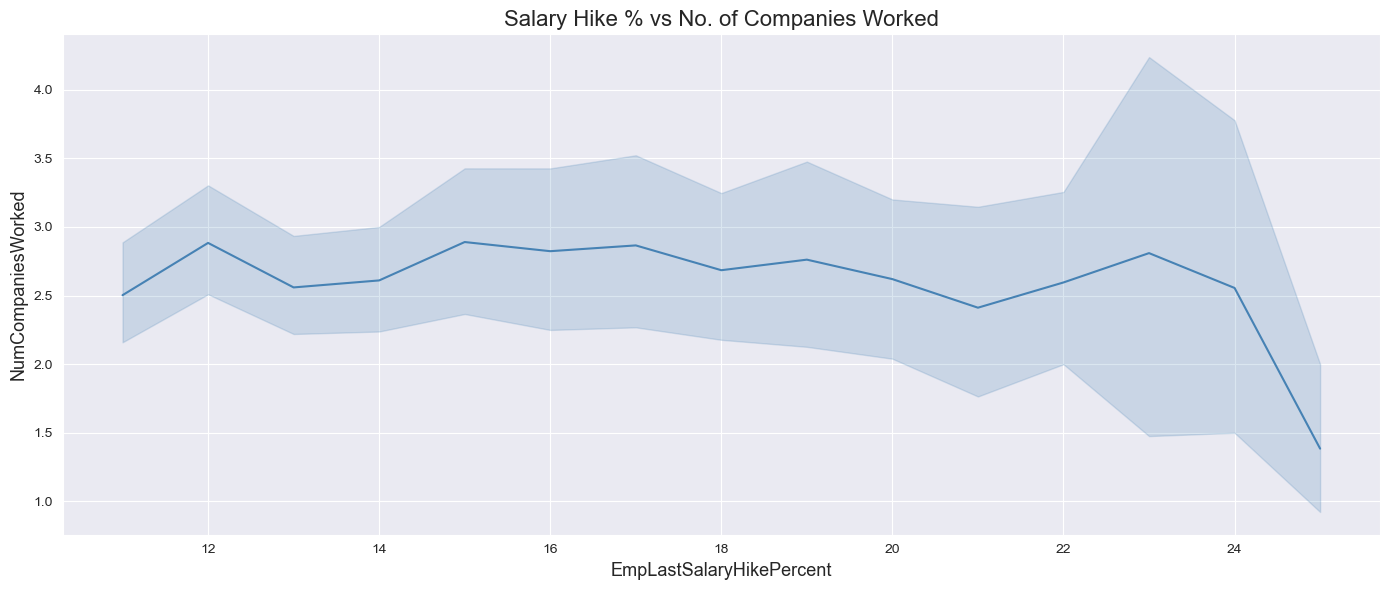

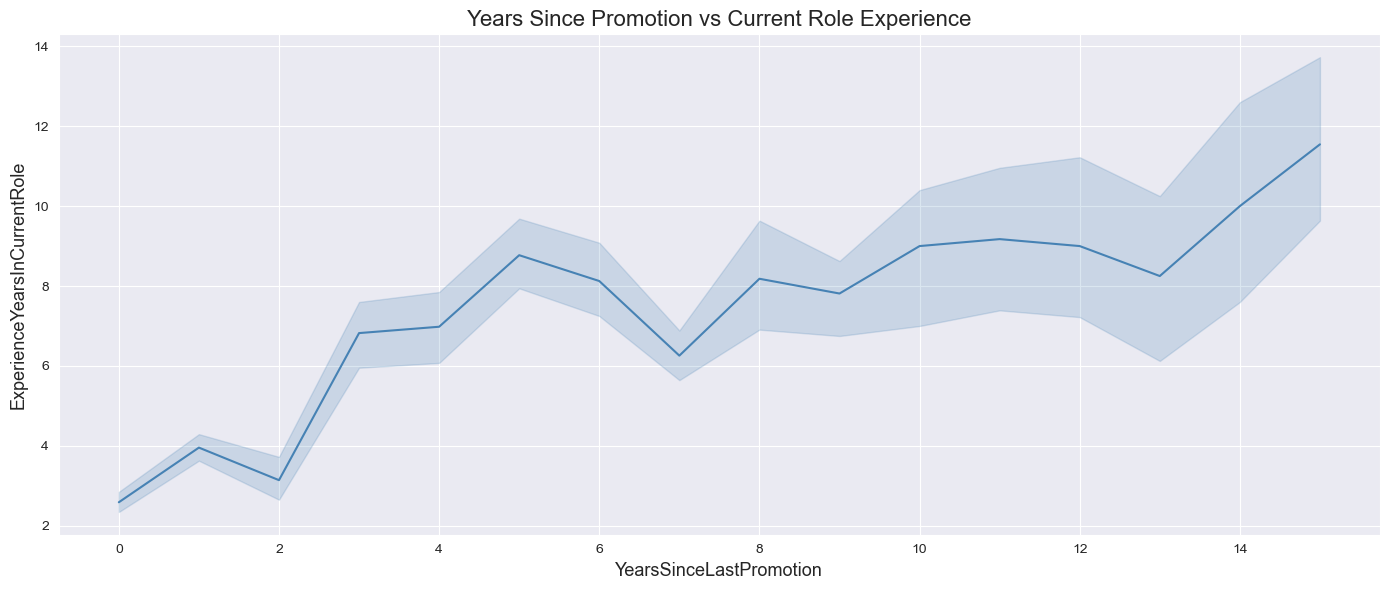

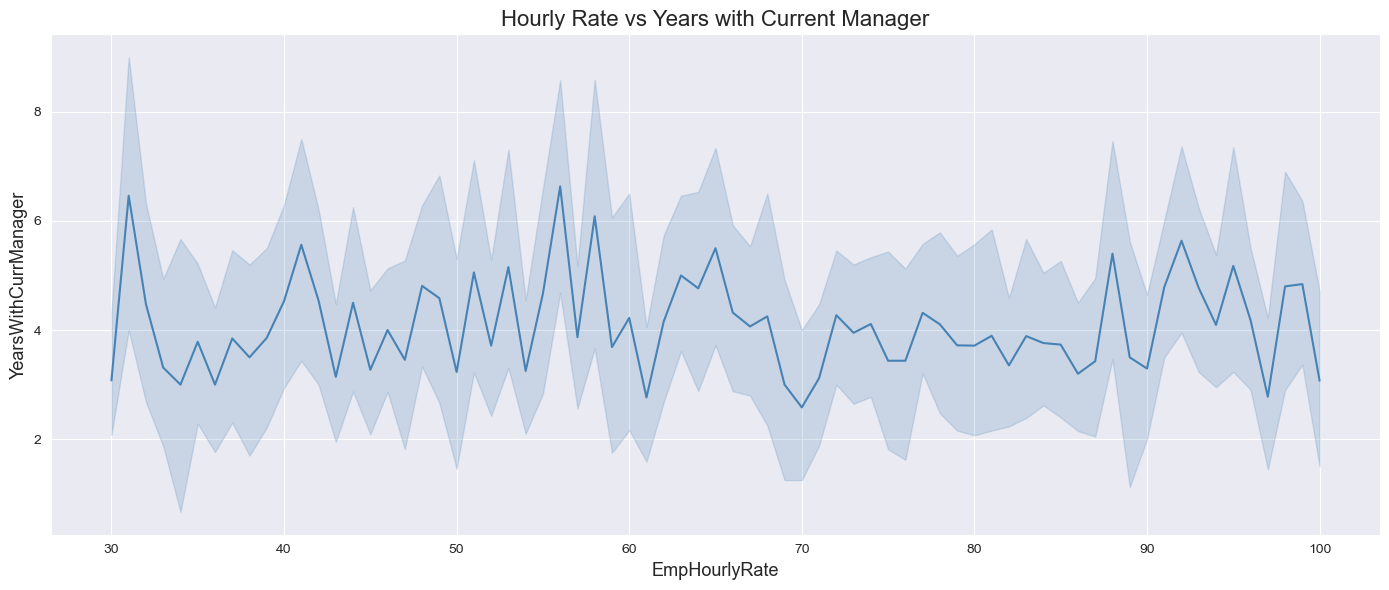

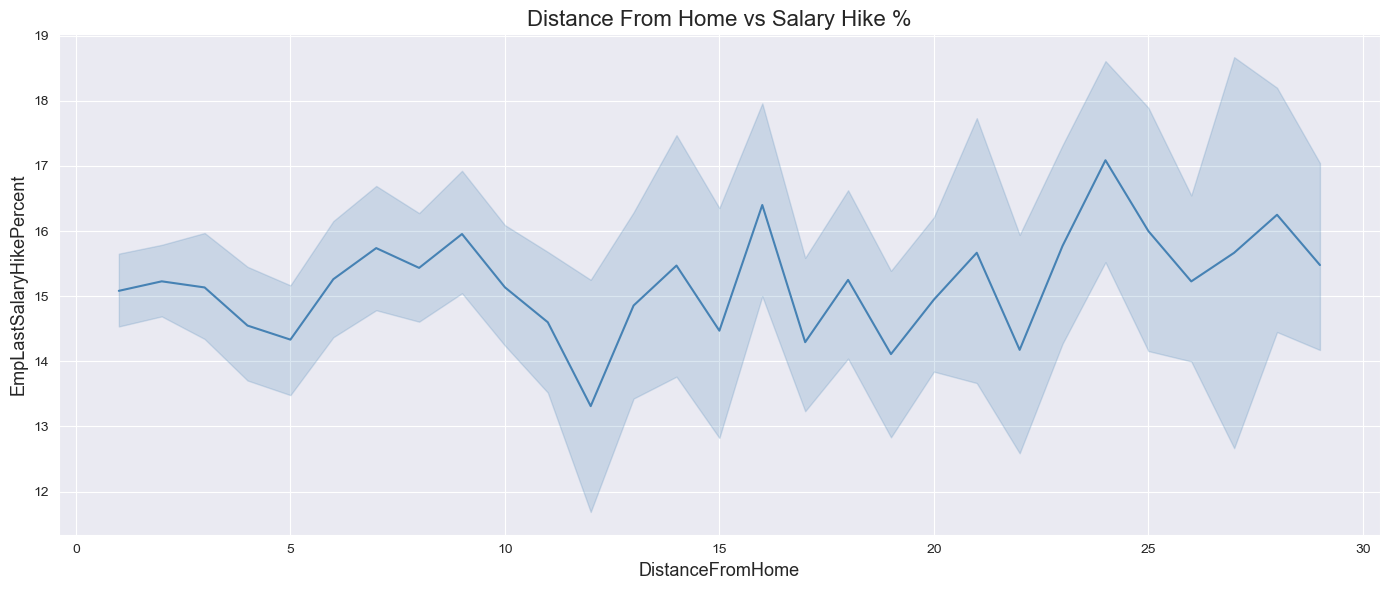

In [8]:
bivariate_pairs = [
    ('Age',                      'TotalWorkExperienceInYears',   'Age vs Total Work Experience'),
    ('ExperienceYearsAtThisCompany','TotalWorkExperienceInYears','Company Experience vs Total Experience'),
    ('EmpLastSalaryHikePercent', 'NumCompaniesWorked',           'Salary Hike % vs No. of Companies Worked'),
    ('YearsSinceLastPromotion',  'ExperienceYearsInCurrentRole', 'Years Since Promotion vs Current Role Experience'),
    ('EmpHourlyRate',            'YearsWithCurrManager',         'Hourly Rate vs Years with Current Manager'),
    ('DistanceFromHome',         'EmpLastSalaryHikePercent',     'Distance From Home vs Salary Hike %'),
]

for x_col, y_col, title in bivariate_pairs:
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=x_col, y=y_col, data=data, color='steelblue')
    plt.title(title, fontsize=16)
    plt.xlabel(x_col, fontsize=13)
    plt.ylabel(y_col, fontsize=13)
    plt.tight_layout()
    plt.show()

**Key Observations:**
- Age and total work experience are **positively correlated** — as age increases, experience grows.
- Employees who have stayed longer at INX have higher total experience.
- Employees who worked at fewer companies tend to receive higher salary hikes.
- Longer tenure in current role is associated with more years since the last promotion — indicating potential promotion gaps.

### Categorical Features vs Performance Rating

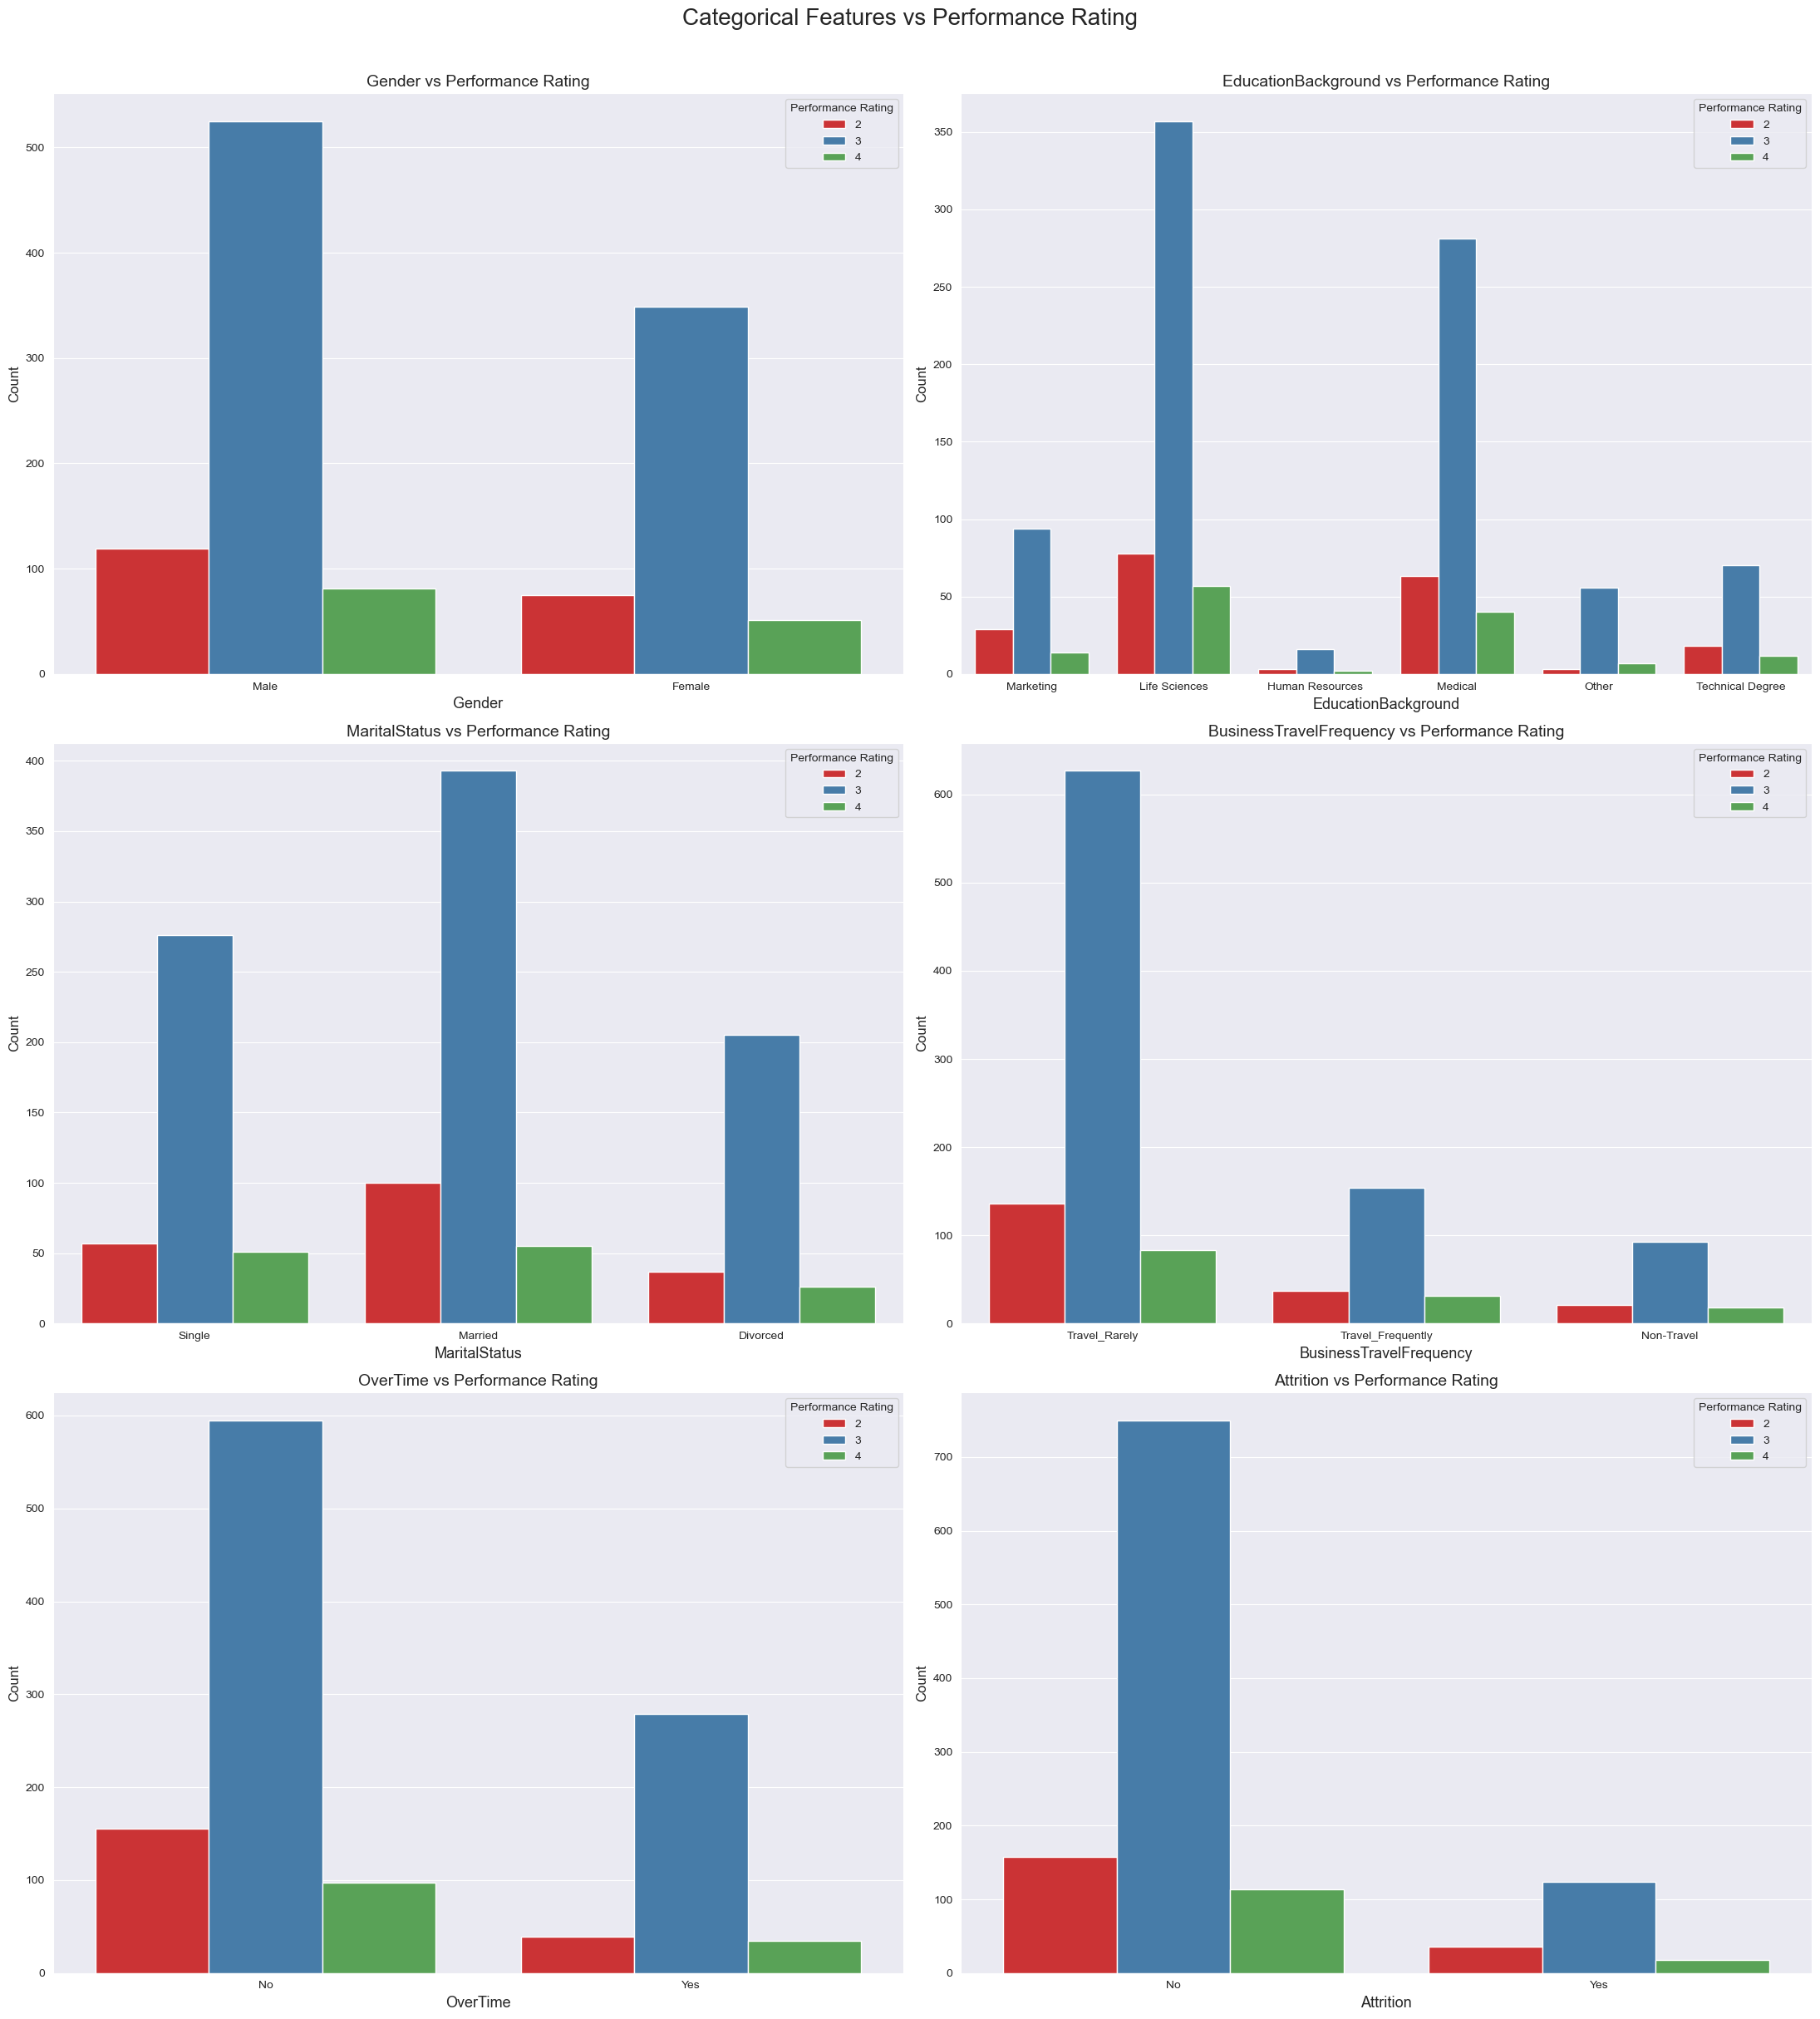

In [9]:
cat_features = ['Gender', 'EducationBackground', 'MaritalStatus',
                'BusinessTravelFrequency', 'OverTime', 'Attrition']

plt.figure(figsize=(22, 24))
for i, col in enumerate(cat_features, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue='PerformanceRating', data=data, palette='Set1')
    plt.xlabel(col, fontsize=13)
    plt.ylabel('Count', fontsize=12)
    plt.title(f'{col} vs Performance Rating', fontsize=14)
    plt.legend(title='Performance Rating', fontsize=10)
plt.suptitle('Categorical Features vs Performance Rating', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

**Key Observations:**
- **Gender:** Both genders are predominantly rated 3; minimal difference in distribution.
- **EducationBackground:** Life Sciences and Medical employees are most frequently rated 3.
- **Attrition:** Employees with performance rating 3 are also most likely to leave — a key retention risk.
- **OverTime:** Overtime workers show a more evenly distributed performance profile across ratings 2, 3, and 4.

### Ordinal/Numerical Features vs Performance Rating

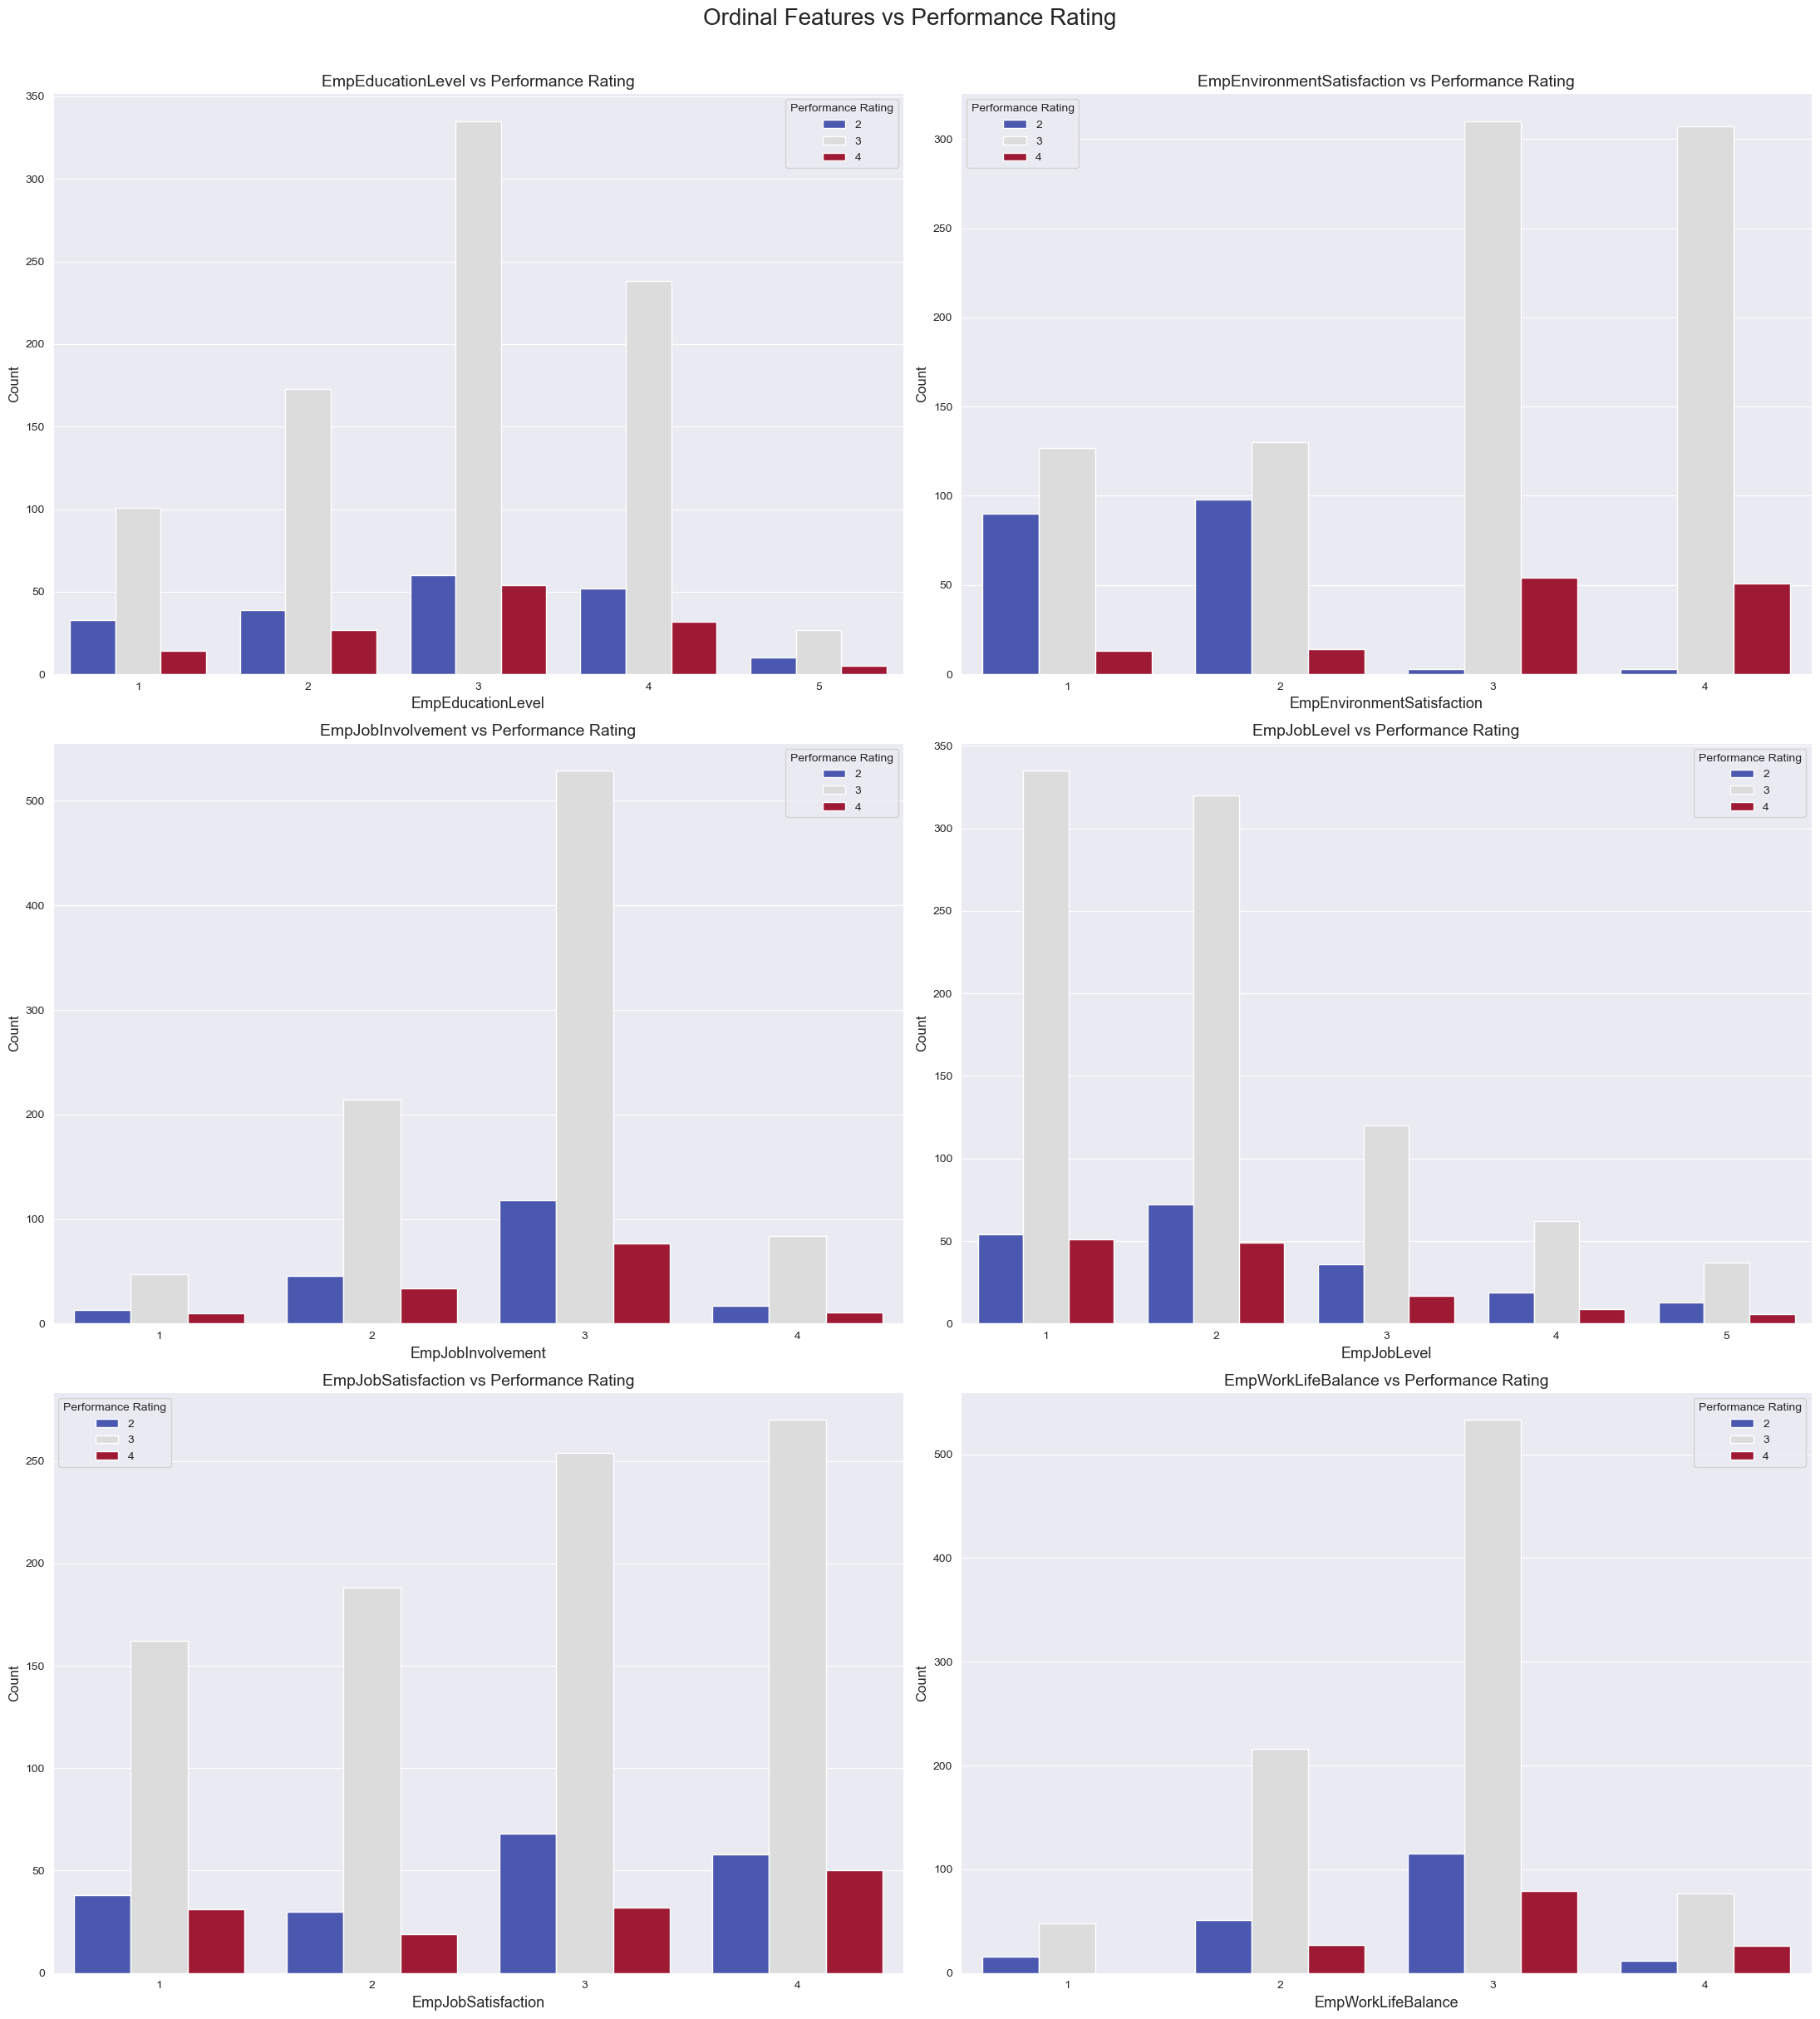

In [10]:
ordinal_features = ['EmpEducationLevel', 'EmpEnvironmentSatisfaction',
                    'EmpJobInvolvement', 'EmpJobLevel',
                    'EmpJobSatisfaction', 'EmpWorkLifeBalance']

plt.figure(figsize=(22, 24))
for i, col in enumerate(ordinal_features, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue='PerformanceRating', data=data, palette='coolwarm')
    plt.xlabel(col, fontsize=13)
    plt.ylabel('Count', fontsize=12)
    plt.title(f'{col} vs Performance Rating', fontsize=14)
    plt.legend(title='Performance Rating', fontsize=10)
plt.suptitle('Ordinal Features vs Performance Rating', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

**Key Observations:**
- **EmpEnvironmentSatisfaction:** Levels 3 & 4 strongly associate with higher performance ratings. Low satisfaction (level 1) correlates with more level-2 performers.
- **EmpWorkLifeBalance:** Level 3 shows the highest concentration of high performers. Level 1 has no rating-4 performers.
- **EmpJobLevel:** Levels 1–3 dominate at performance rating 3; senior levels (4–5) show mixed results.

---
## Multivariate Analysis

**Goal:** Examine the relationship between two input features with respect to the target variable (`PerformanceRating`).

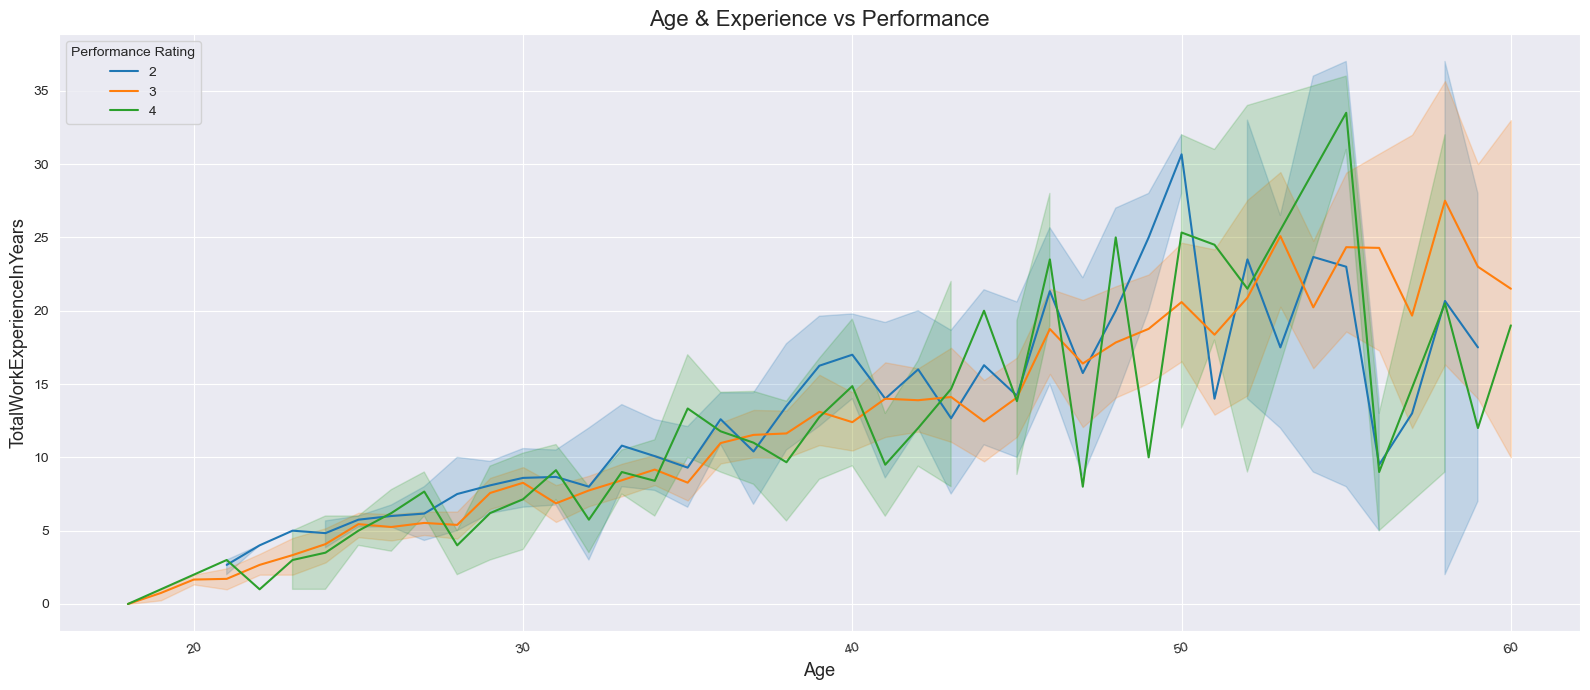

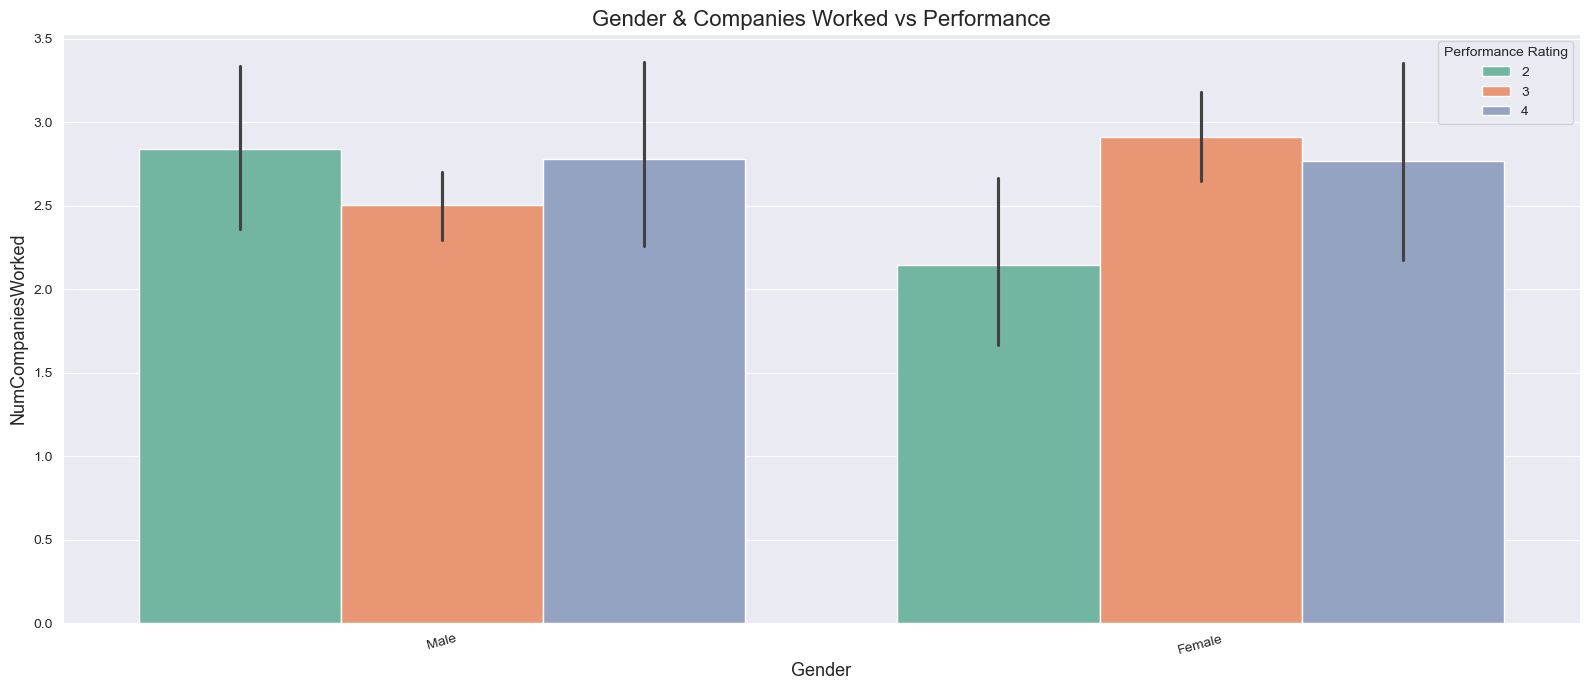

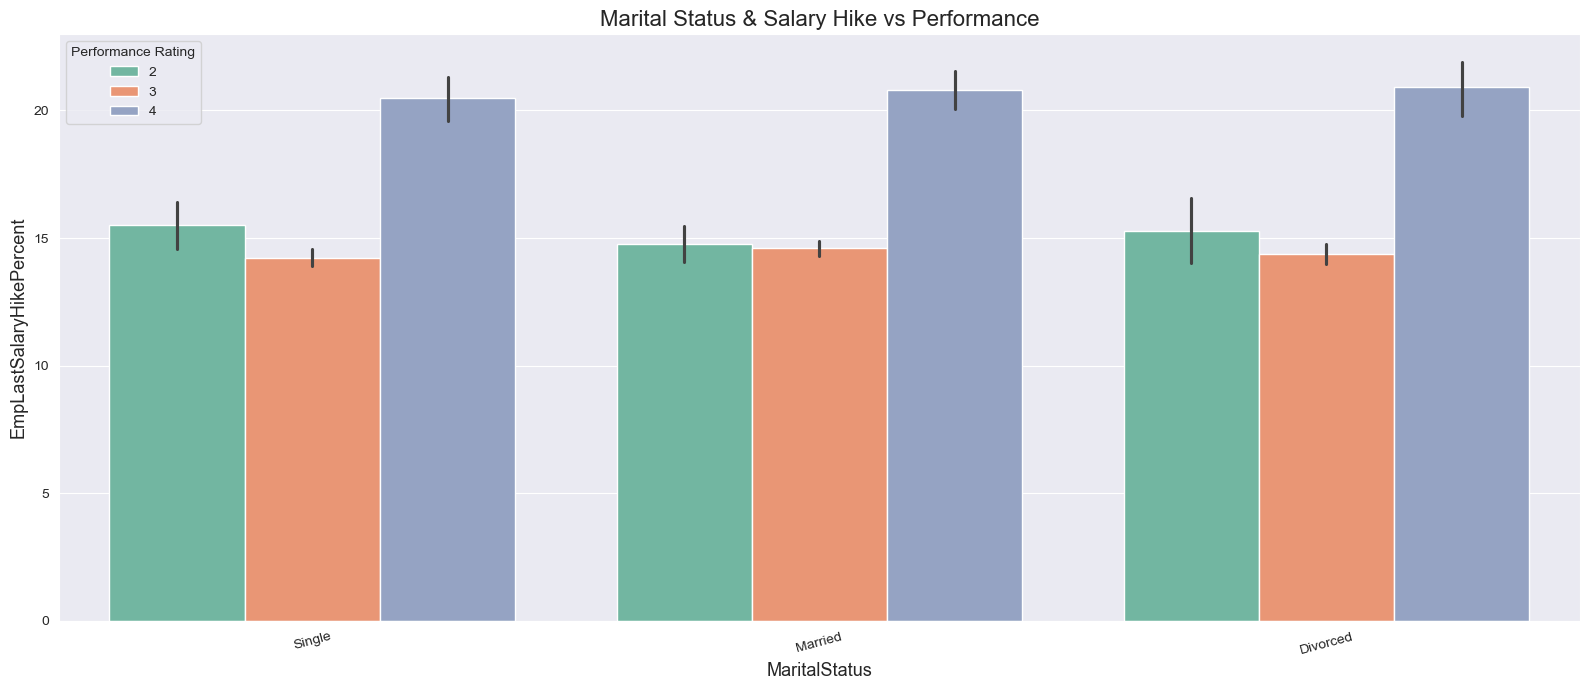

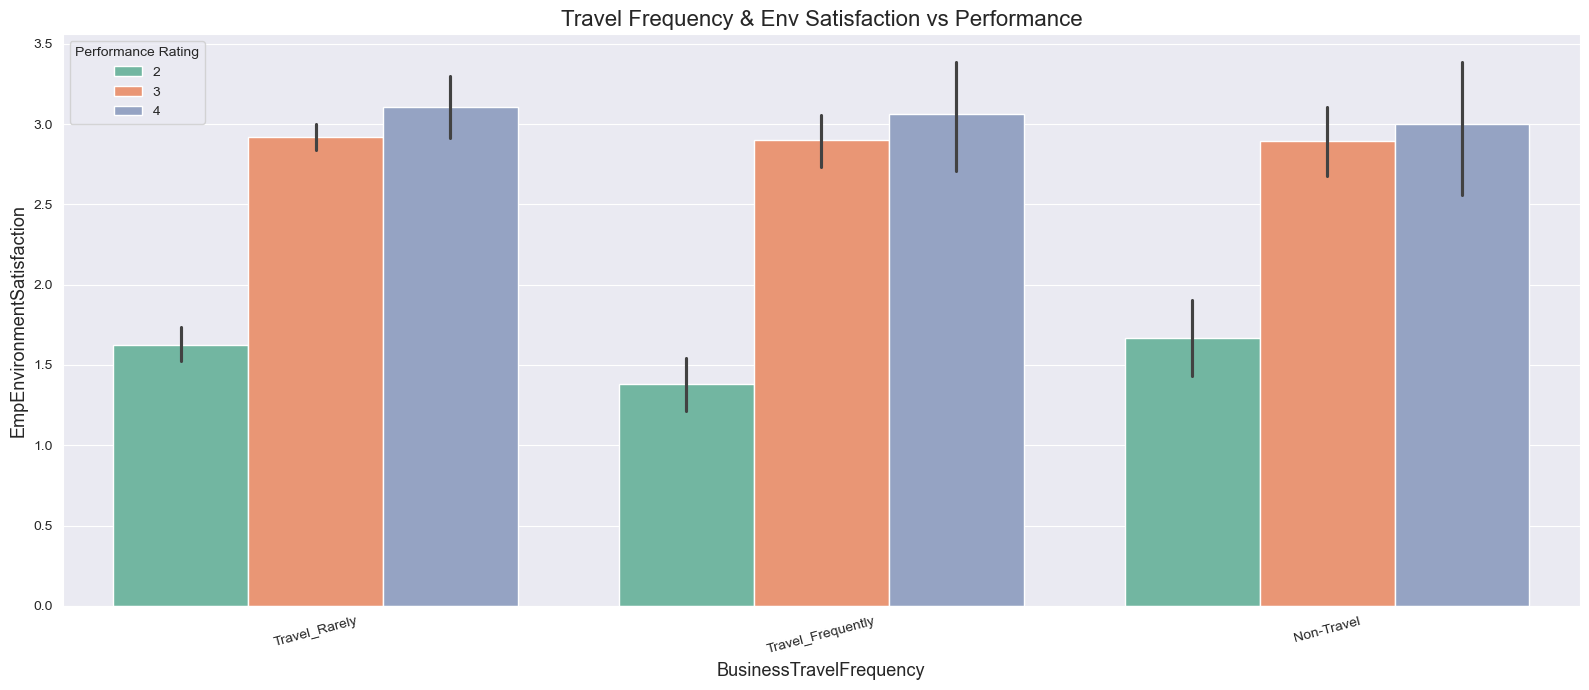

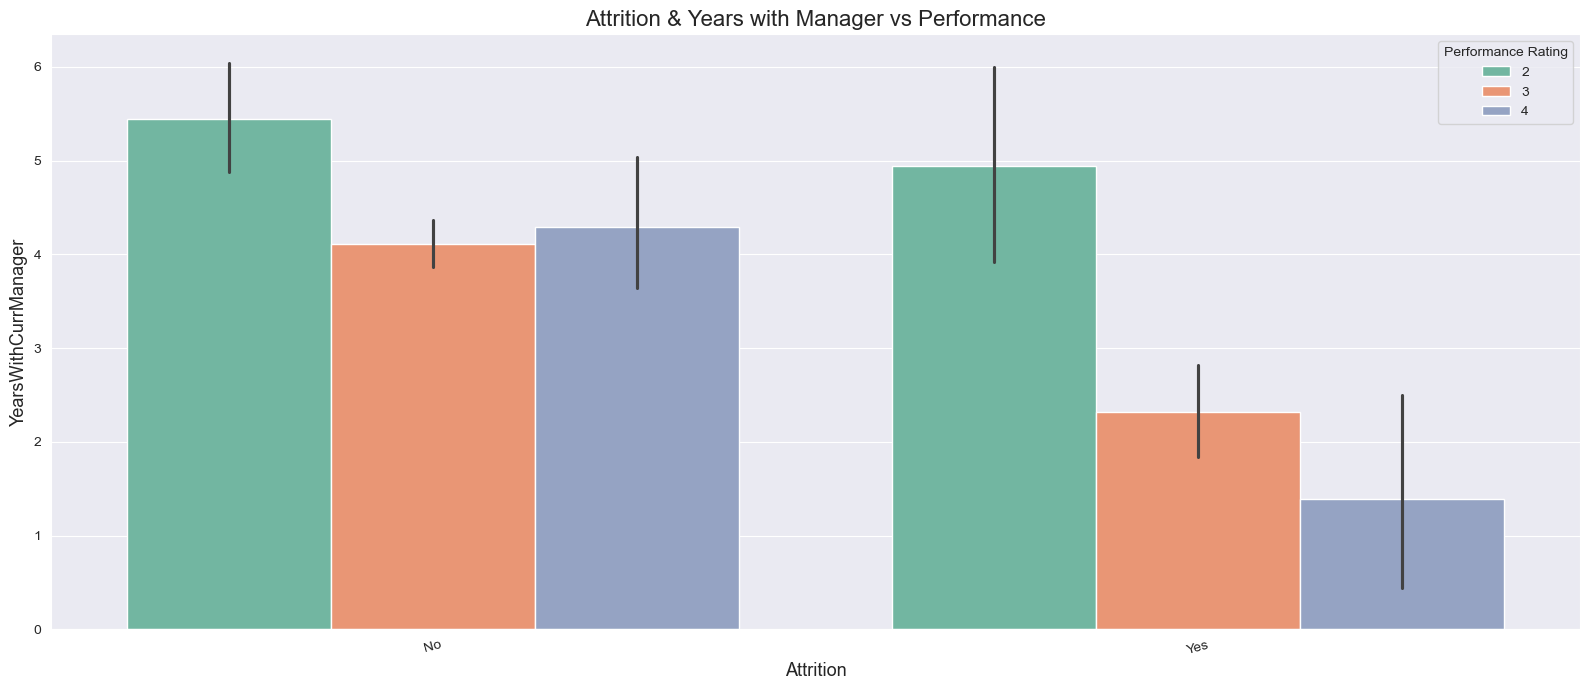

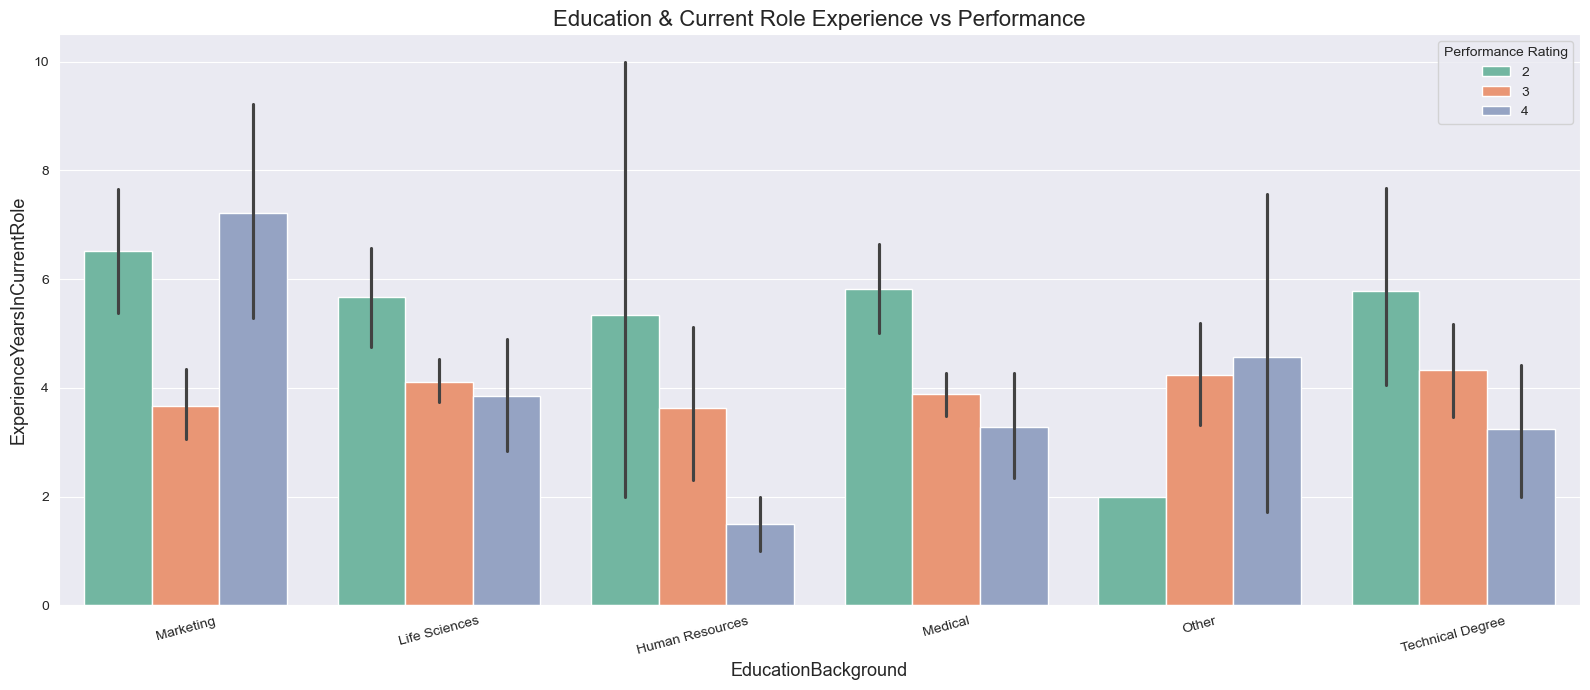

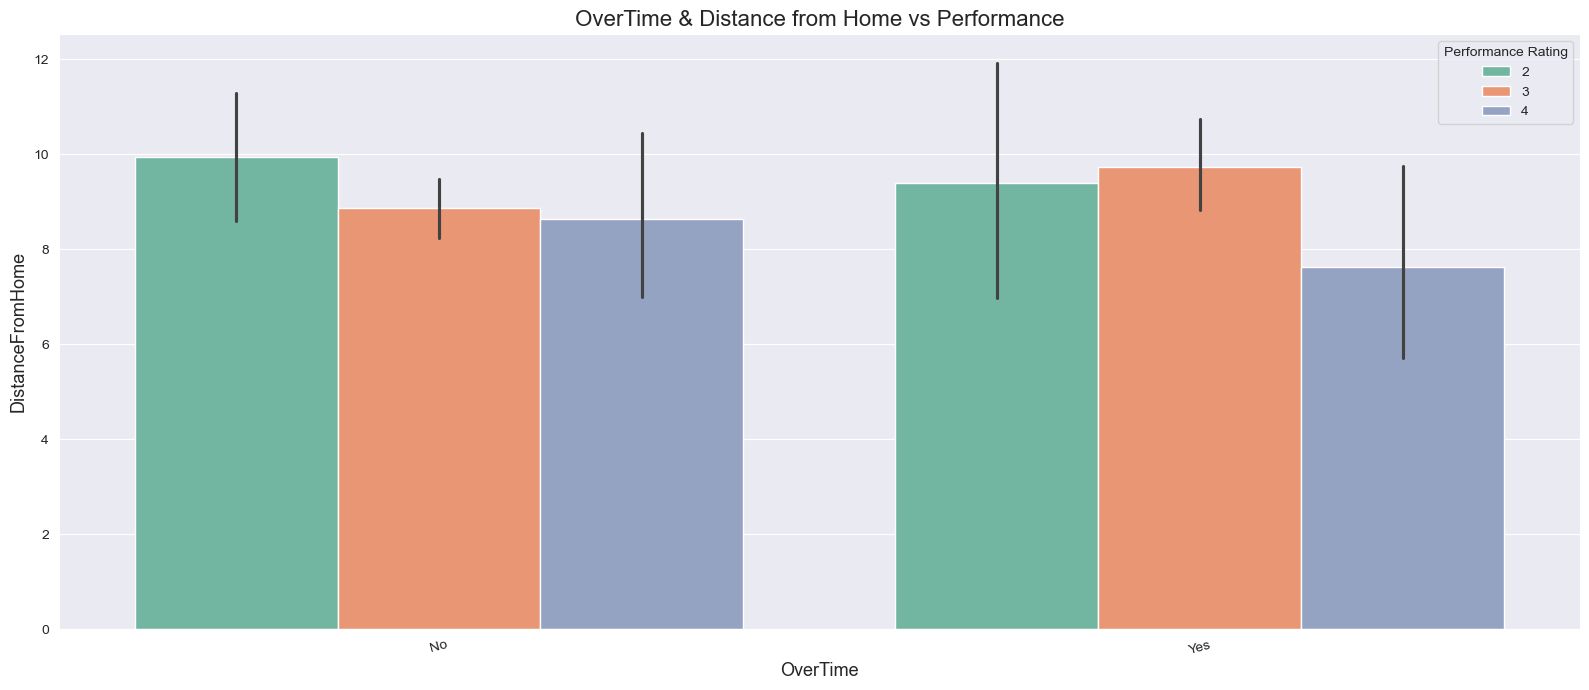

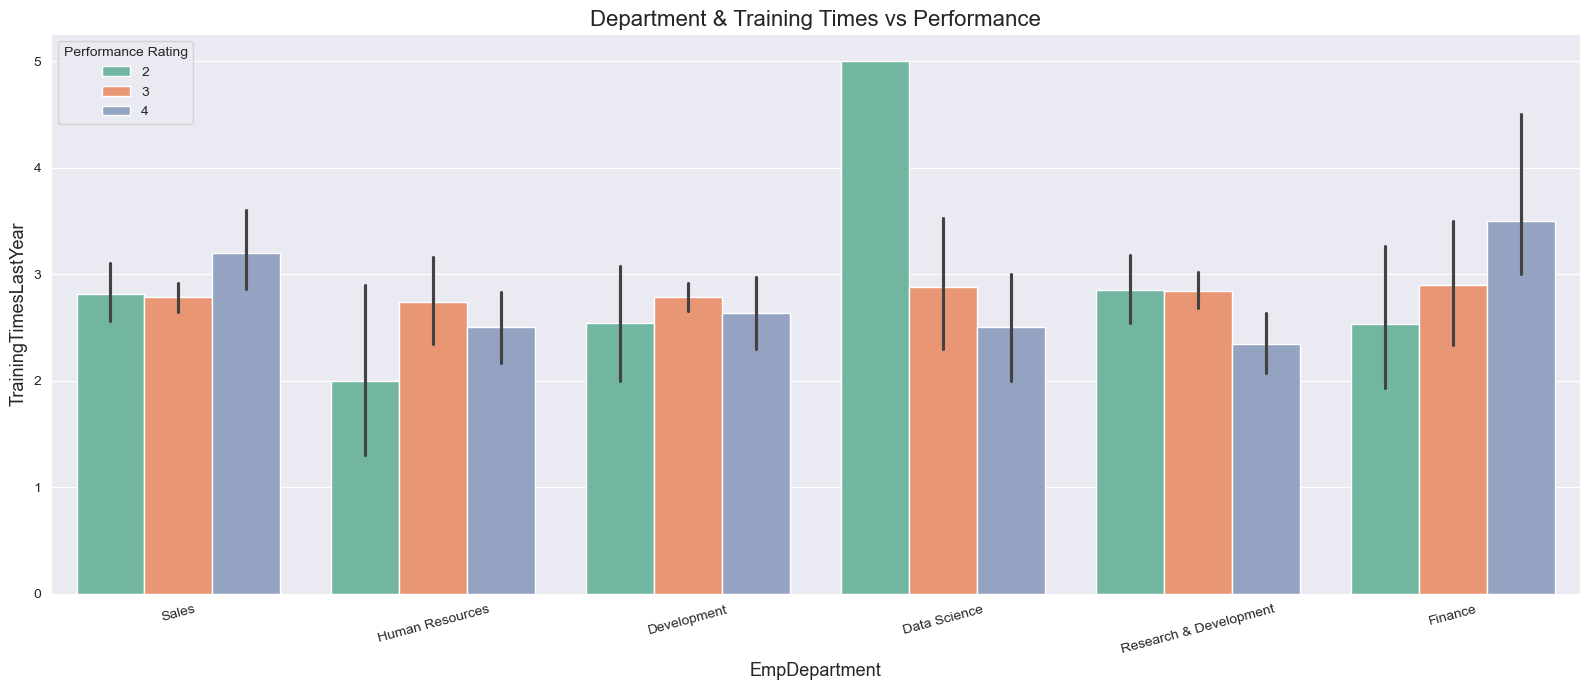

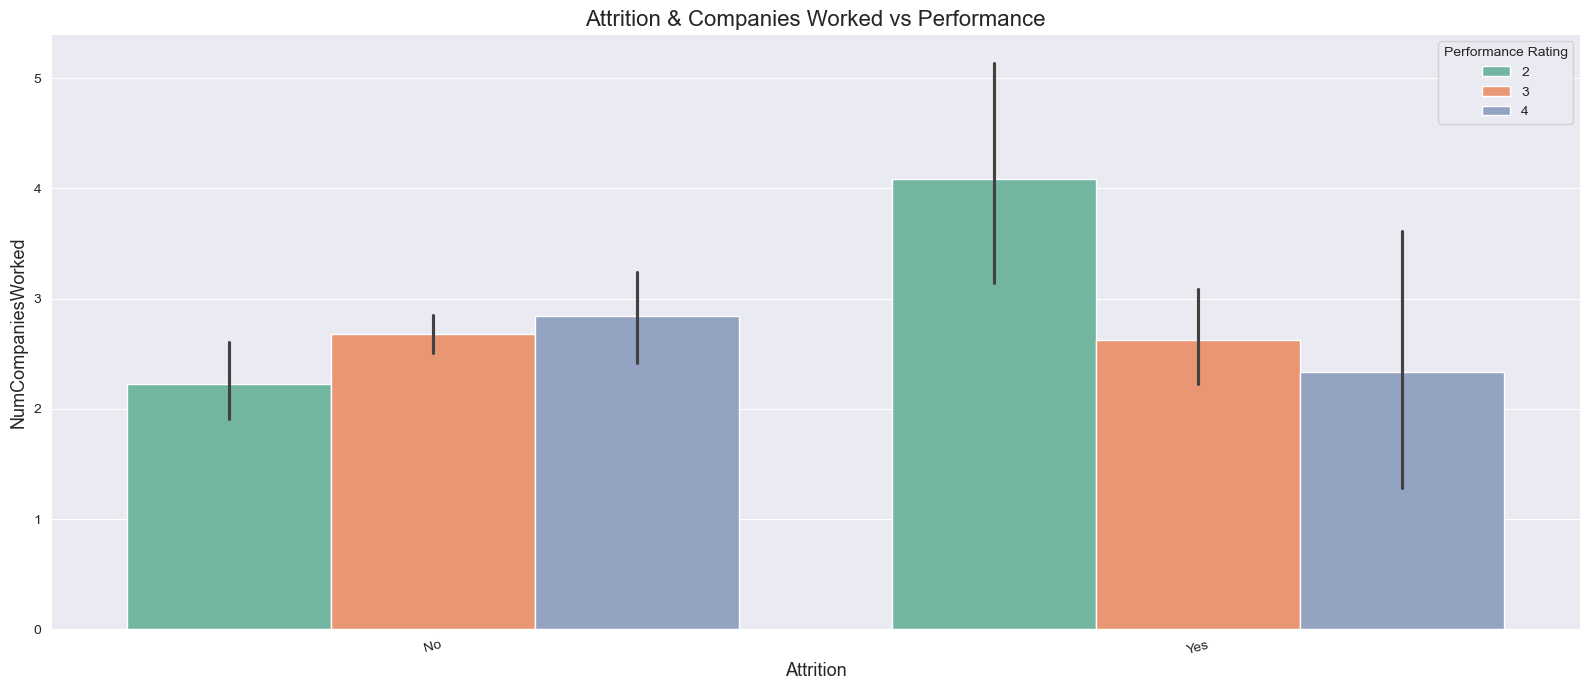

In [11]:
multivariate_plots = [
    ('Age',                    'TotalWorkExperienceInYears',  'line', 'Age & Experience vs Performance'),
    ('Gender',                 'NumCompaniesWorked',           'bar',  'Gender & Companies Worked vs Performance'),
    ('MaritalStatus',          'EmpLastSalaryHikePercent',     'bar',  'Marital Status & Salary Hike vs Performance'),
    ('BusinessTravelFrequency','EmpEnvironmentSatisfaction',   'bar',  'Travel Frequency & Env Satisfaction vs Performance'),
    ('Attrition',              'YearsWithCurrManager',         'bar',  'Attrition & Years with Manager vs Performance'),
    ('EducationBackground',    'ExperienceYearsInCurrentRole', 'bar',  'Education & Current Role Experience vs Performance'),
    ('OverTime',               'DistanceFromHome',             'bar',  'OverTime & Distance from Home vs Performance'),
    ('EmpDepartment',          'TrainingTimesLastYear',        'bar',  'Department & Training Times vs Performance'),
    ('Attrition',              'NumCompaniesWorked',           'bar',  'Attrition & Companies Worked vs Performance'),
]

for x, y_axis, plot_type, title in multivariate_plots:
    plt.figure(figsize=(16, 7))
    if plot_type == 'line':
        sns.lineplot(x=x, y=y_axis, hue='PerformanceRating', data=data, palette='tab10')
    else:
        sns.barplot(x=x, y=y_axis, hue='PerformanceRating', data=data, palette='Set2')
    plt.title(title, fontsize=16)
    plt.xlabel(x, fontsize=13)
    plt.ylabel(y_axis, fontsize=13)
    plt.xticks(rotation=15)
    plt.legend(title='Performance Rating', fontsize=10)
    plt.tight_layout()
    plt.show()

**Key Observations from Multivariate Analysis:**

- Employees with both high age and high total experience are more likely to achieve **performance rating 4**.
- Across all marital statuses, a **higher salary hike percentage** (≥20%) is associated with **rating 4**.
- Employees with **high environment satisfaction** consistently show ratings 3 & 4 regardless of travel frequency.
- Employees with a **rating of 4** and long tenure with their current manager are **less likely to leave** — a valuable retention insight.
- Data Science department employees with more training sessions tend to have **lower performance ratings** — suggesting training overload or misalignment.
- Employees who have worked at fewer companies and do not leave tend to have **stable performance ratings**.

---
## Visualisation Conclusion

**Three features consistently emerge as the strongest positive predictors of high performance ratings:**

| Rank | Feature | Pattern |
|---|---|---|
| **1** | `EmpEnvironmentSatisfaction` | Levels 3 & 4 → higher performance across all departments and genders |
| **2** | `EmpLastSalaryHikePercent` | 20–22% hike → performance rating 4 |
| **3** | `EmpWorkLifeBalance` | Level 3 → highest concentration of high performers |

These findings will guide both the feature importance analysis and the business recommendations.